In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve


In [2]:
df1 = pd.read_csv("bank-additional-full.csv")
df = df1

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


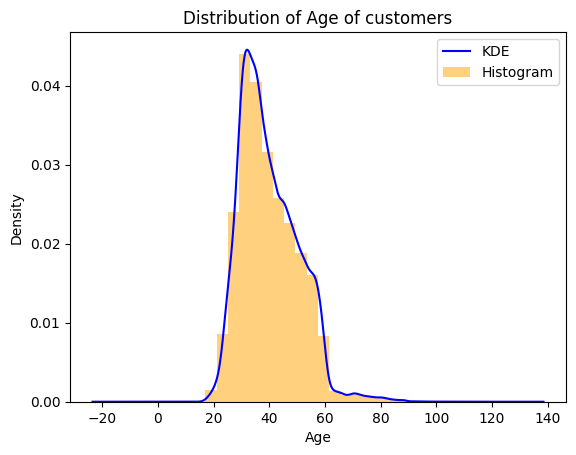

In [6]:
df['age'].plot(kind='kde', label='KDE', color='blue')  # KDE line
plt.hist(df['age'], bins=20, density=True, alpha=0.5, label='Histogram', color='orange')  # Histogram

plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Distribution of Age of customers')
plt.legend()
plt.show()


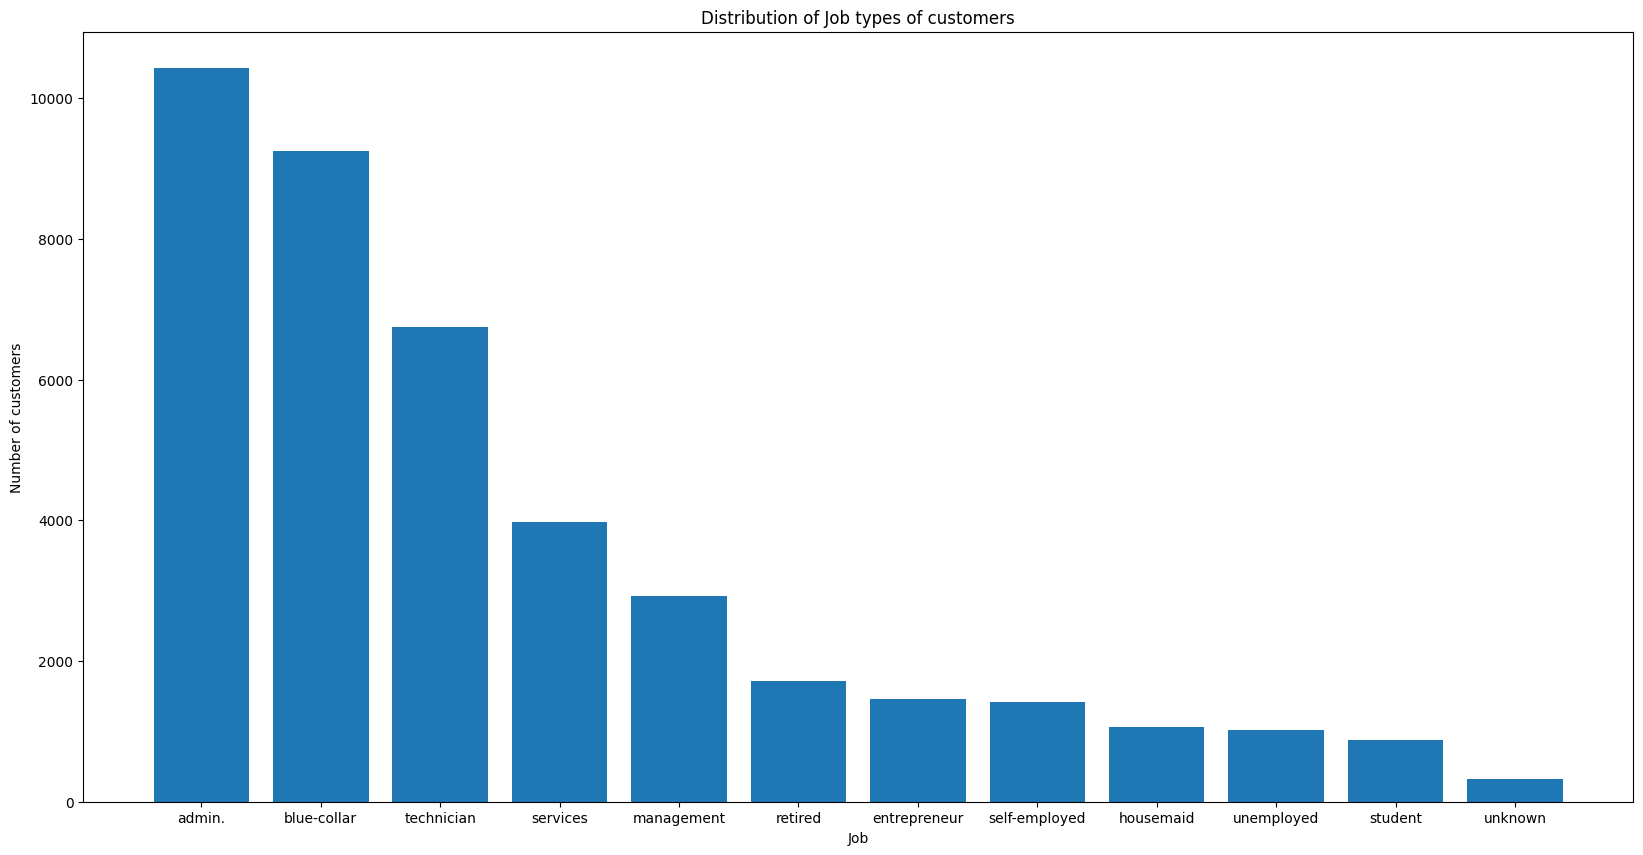

In [7]:
plt.figure(figsize=(20,10))
plt.bar(df['job'].value_counts().index, df['job'].value_counts().values)
plt.xlabel('Job')
plt.ylabel('Number of customers')
plt.title('Distribution of Job types of customers')
plt.show()

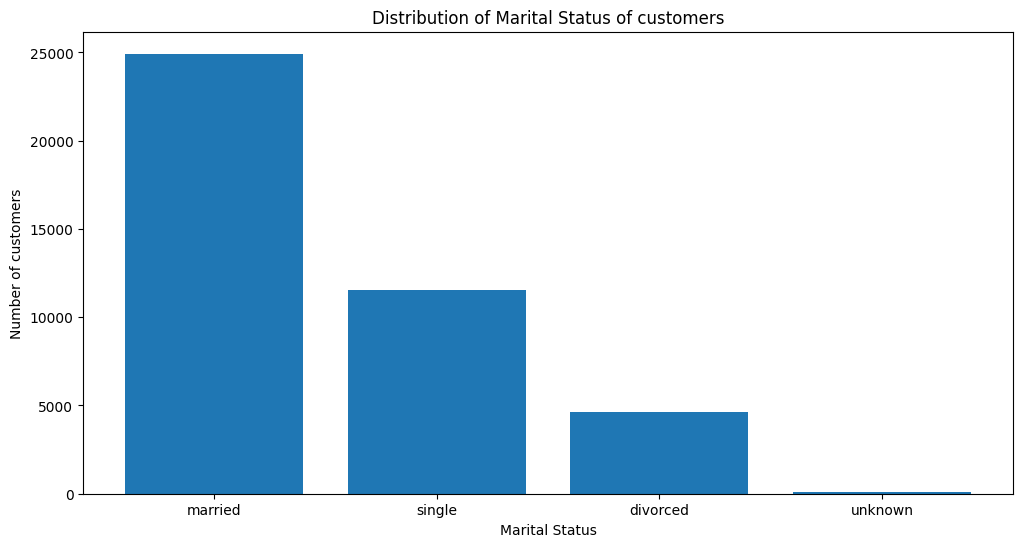

In [8]:
plt.figure(figsize=(12,6))
plt.bar(df['marital'].value_counts().index, df['marital'].value_counts().values)
plt.xlabel('Marital Status')
plt.ylabel('Number of customers')
plt.title('Distribution of Marital Status of customers')
plt.show()

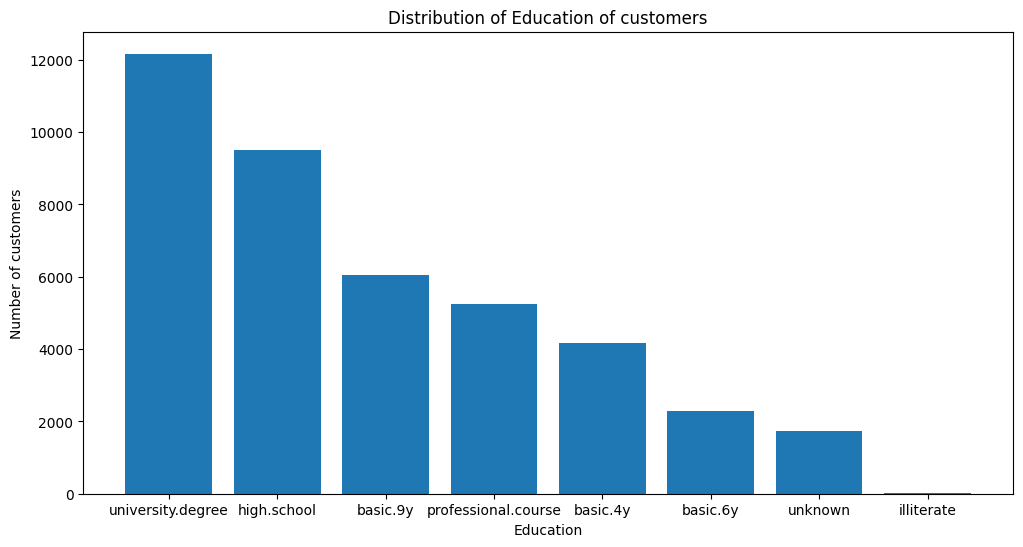

In [9]:
plt.figure(figsize=(12,6))
plt.bar(df['education'].value_counts().index, df['education'].value_counts().values)
plt.xlabel('Education')
plt.ylabel('Number of customers')
plt.title('Distribution of Education of customers')
plt.show()

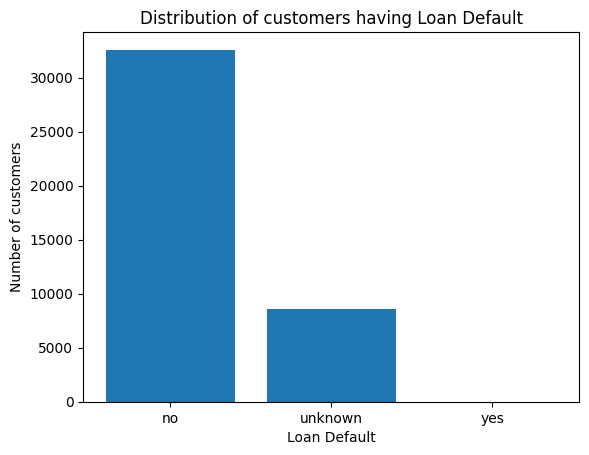

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64


In [10]:
#plt.figure(figsize=(12,6))
plt.bar(df['default'].value_counts().index, df['default'].value_counts().values)
plt.xlabel('Loan Default')
plt.ylabel('Number of customers')
plt.title('Distribution of customers having Loan Default')
plt.show()

print(df['default'].value_counts())

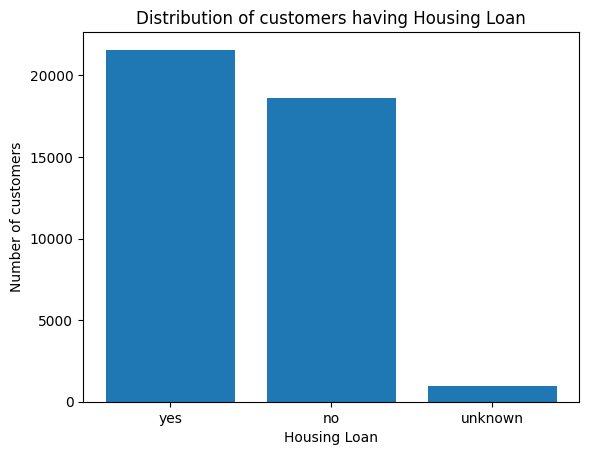

In [11]:
#plt.figure(figsize=(12,6))
plt.bar(df['housing'].value_counts().index, df['housing'].value_counts().values)
plt.xlabel('Housing Loan')
plt.ylabel('Number of customers')
plt.title('Distribution of customers having Housing Loan')
plt.show()

#print(df['default'].value_counts())

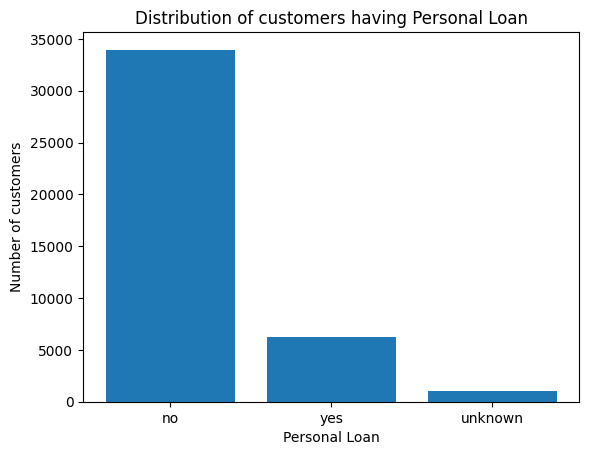

In [12]:
#plt.figure(figsize=(12,6))
plt.bar(df['loan'].value_counts().index, df['loan'].value_counts().values)
plt.xlabel('Personal Loan')
plt.ylabel('Number of customers')
plt.title('Distribution of customers having Personal Loan')
plt.show()

#print(df['default'].value_counts())

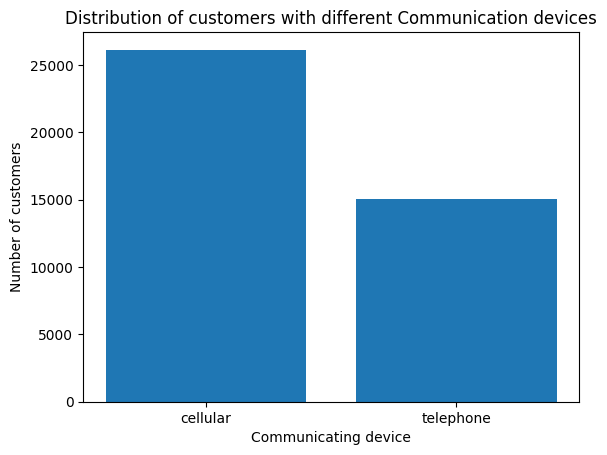

In [13]:
#plt.figure(figsize=(12,6))
plt.bar(df['contact'].value_counts().index, df['contact'].value_counts().values)
plt.xlabel('Communicating device')
plt.ylabel('Number of customers')
plt.title('Distribution of customers with different Communication devices')
plt.show()

#print(df['default'].value_counts())

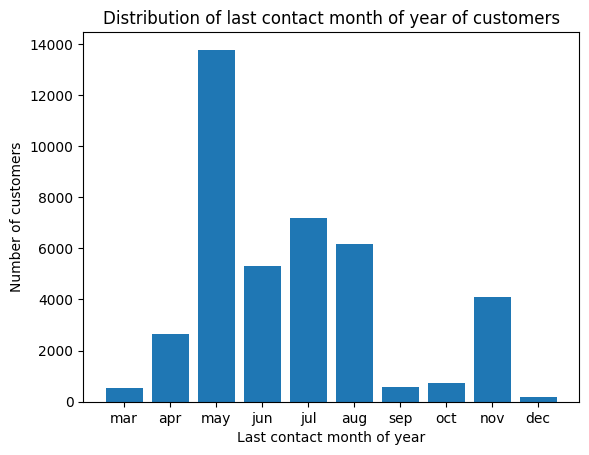

In [14]:
#plt.figure(figsize=(12,6))
months = df['month'].value_counts().index[[8, 5, 0, 3, 1, 2, 7, 6, 4, 9]]
months_freq = df['month'].value_counts().values[[8, 5, 0, 3, 1, 2, 7, 6, 4, 9]]

plt.bar(months, months_freq)
plt.xlabel('Last contact month of year')
plt.ylabel('Number of customers')
plt.title('Distribution of last contact month of year of customers')
plt.show()

#print(df['default'].value_counts())

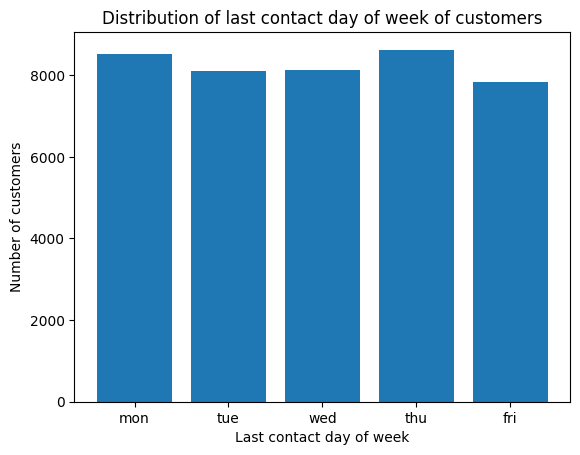

In [15]:
#plt.figure(figsize=(12,6))
days = df['day_of_week'].value_counts().index[[1, 3, 2, 0, 4]]
days_freq = df['day_of_week'].value_counts().values[[1, 3, 2, 0, 4]]

plt.bar(days, days_freq)
plt.xlabel('Last contact day of week')
plt.ylabel('Number of customers')
plt.title('Distribution of last contact day of week of customers')
plt.show()

#print(df['default'].value_counts())

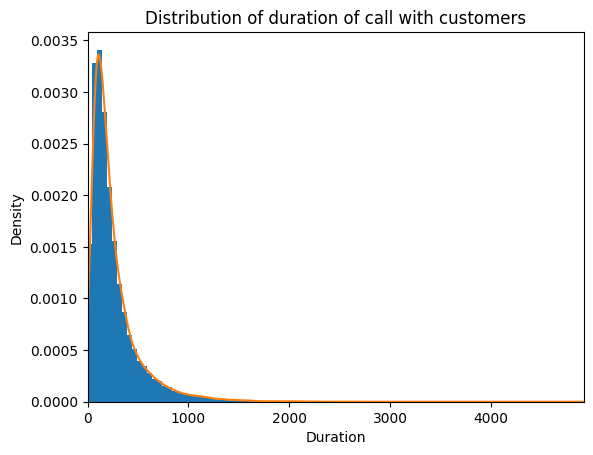

2313     3366
4213     3078
6280     3094
7727     3631
12029    3183
13820    3643
19632    3422
20996    3322
22192    4199
24004    3253
24043    3284
24091    4918
27833    3076
36043    3509
40537    3785
Name: duration, dtype: int64


In [16]:
plt.hist(df['duration'], bins=100, density=True)
df['duration'].plot(kind='kde', xlim=(0, df['duration'].max()))

plt.title('Distribution of duration of call with customers')
plt.xlabel('Duration')
plt.show()

print(df[df['duration'] > 3000]['duration'])

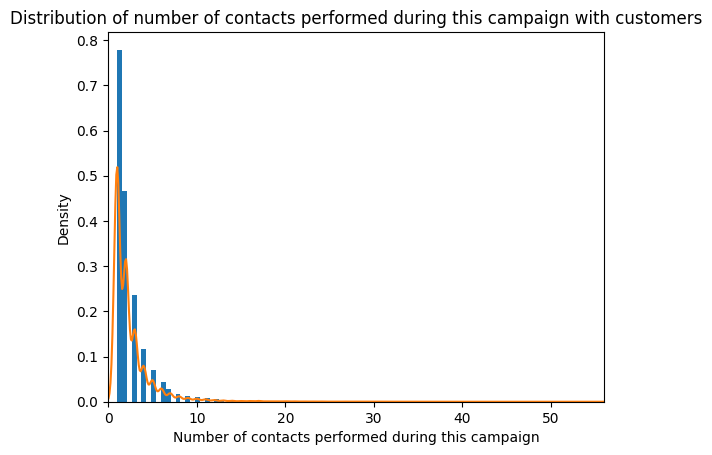

In [17]:

plt.hist(df['campaign'], bins=100, density=True)
df['campaign'].plot(kind='kde', xlim=(0, df['campaign'].max()))

plt.title('Distribution of number of contacts performed during this campaign with customers')
plt.xlabel('Number of contacts performed during this campaign')
plt.show()

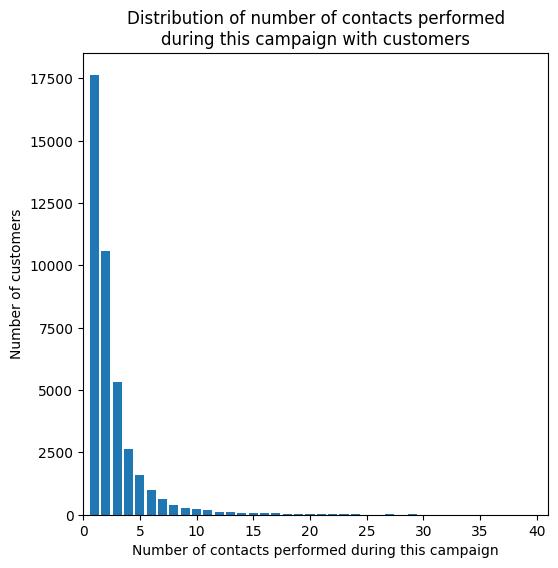

4107     56
4114     39
4168     42
5304     42
11033    41
11593    37
11769    40
13447    43
18728    43
18754    40
Name: campaign, dtype: int64


In [18]:
plt.figure(figsize=(6,6))
plt.bar(df['campaign'].value_counts().index, df['campaign'].value_counts().values)
plt.xlim(0, df['campaign'].value_counts().index[-1])
plt.xlabel('Number of contacts performed during this campaign')
plt.ylabel('Number of customers')
plt.title('Distribution of number of contacts performed\nduring this campaign with customers')
plt.show()

print(df[df['campaign'] > 35]['campaign'])

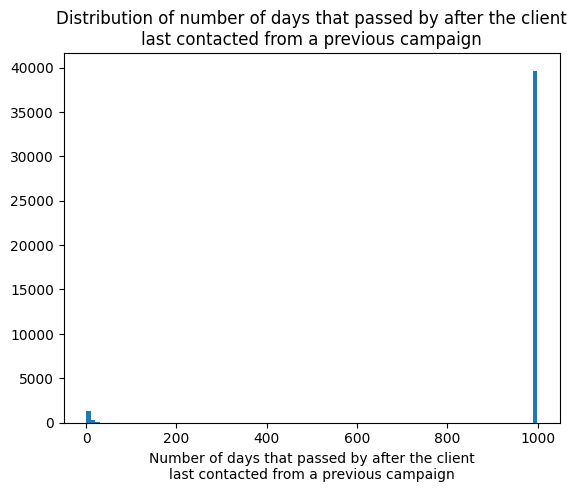

In [19]:
plt.hist(df['pdays'], bins=100)

plt.title('Distribution of number of days that passed by after the client\nlast contacted from a previous campaign')
plt.xlabel('Number of days that passed by after the client\nlast contacted from a previous campaign')
plt.show()

In [20]:
df['pdays'] = df['pdays'].astype('object')

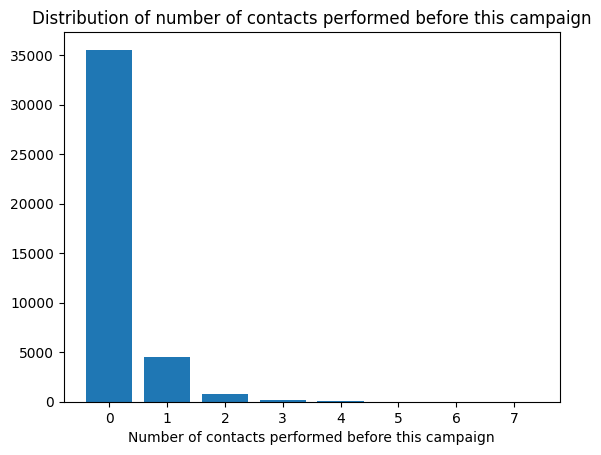

In [21]:
plt.bar(df['previous'].value_counts().index, df['previous'].value_counts().values)

plt.title('Distribution of number of contacts performed before this campaign')
plt.xlabel('Number of contacts performed before this campaign')
plt.show()

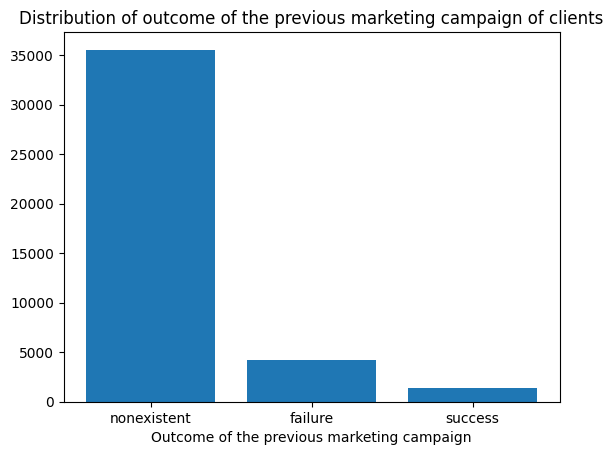

In [22]:
plt.bar(df['poutcome'].value_counts().index, df['poutcome'].value_counts().values)

plt.title('Distribution of outcome of the previous marketing campaign of clients')
plt.xlabel('Outcome of the previous marketing campaign')
plt.show()

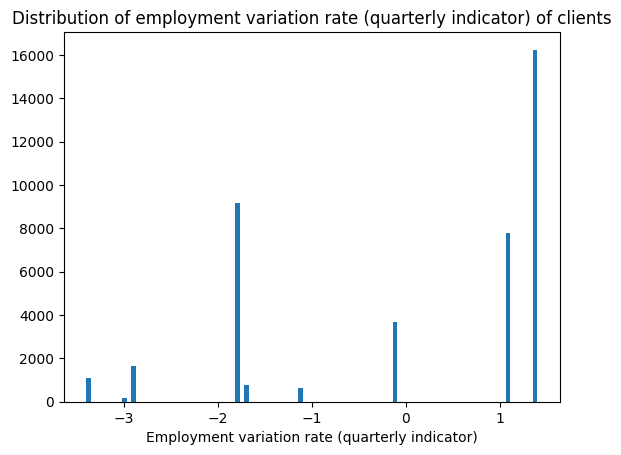

emp.var.rate
 1.4    16234
-1.8     9184
 1.1     7763
-0.1     3683
-2.9     1663
-3.4     1071
-1.7      773
-1.1      635
-3.0      172
-0.2       10
Name: count, dtype: int64


In [23]:
plt.hist(df['emp.var.rate'], bins=100)

plt.title('Distribution of employment variation rate (quarterly indicator) of clients')
plt.xlabel('Employment variation rate (quarterly indicator)')
plt.show()

print(df['emp.var.rate'].value_counts())

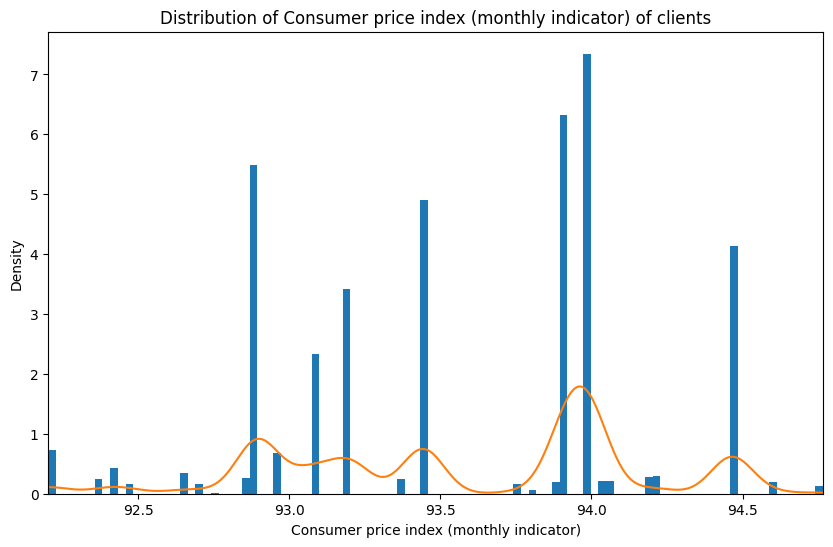

In [24]:
plt.figure(figsize=(10,6))
plt.hist(df['cons.price.idx'], bins=100, density=True)
df['cons.price.idx'].plot(kind='kde', xlim=(df['cons.price.idx'].min(), df['cons.price.idx'].max()))
plt.title('Distribution of Consumer price index (monthly indicator) of clients')
plt.xlabel('Consumer price index (monthly indicator)')
plt.show()

#print(df['cons.price.idx'].value_counts())

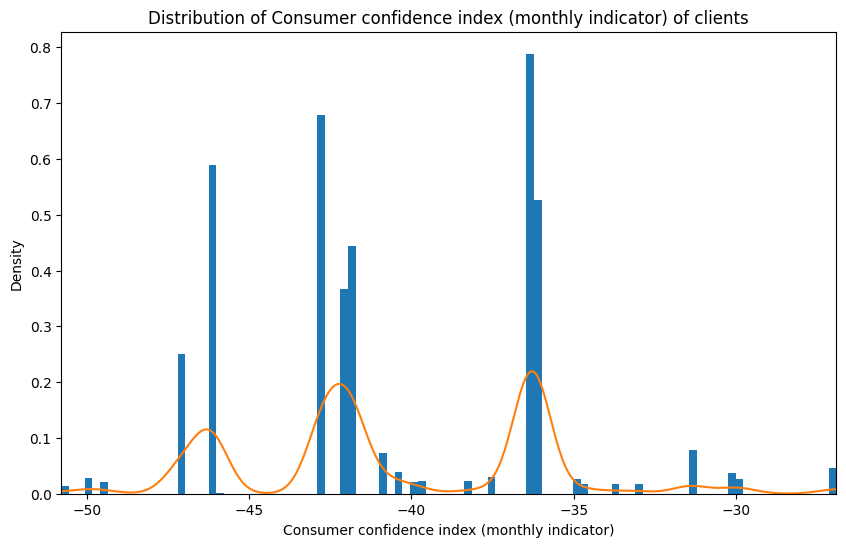

In [25]:
plt.figure(figsize=(10,6))
plt.hist(df['cons.conf.idx'], bins=100, density=True)
df['cons.conf.idx'].plot(kind='kde', xlim=(df['cons.conf.idx'].min(), df['cons.conf.idx'].max()))
plt.title('Distribution of Consumer confidence index (monthly indicator) of clients')
plt.xlabel('Consumer confidence index (monthly indicator)')
plt.show()

#print(df['cons.price.idx'].value_counts())

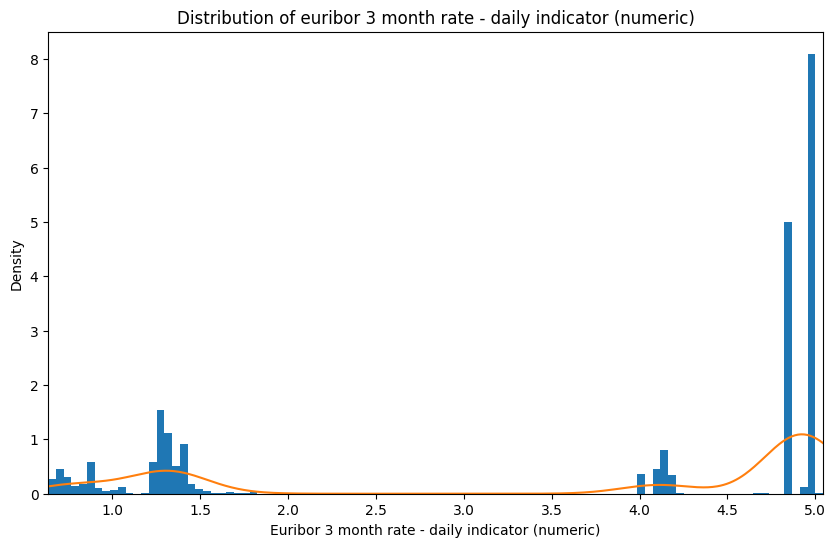

In [26]:
plt.figure(figsize=(10,6))
plt.hist(df['euribor3m'], bins=100, density=True)
df['euribor3m'].plot(kind='kde', xlim=(df['euribor3m'].min(), df['euribor3m'].max()))
plt.title('Distribution of euribor 3 month rate - daily indicator (numeric)')
plt.xlabel('Euribor 3 month rate - daily indicator (numeric)')
plt.show()

#print(df['cons.price.idx'].value_counts())

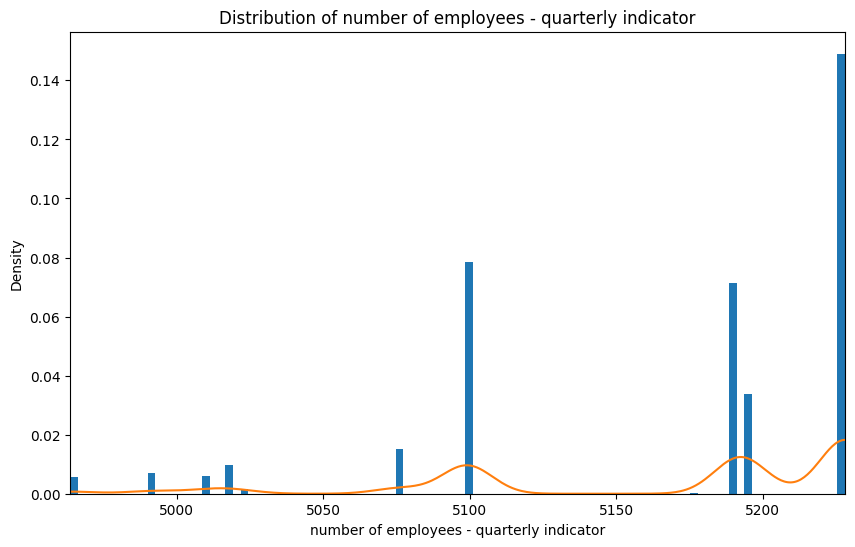

In [27]:
plt.figure(figsize=(10,6))
plt.hist(df['nr.employed'], bins=100, density=True)
df['nr.employed'].plot(kind='kde', xlim=(df['nr.employed'].min(), df['nr.employed'].max()))
plt.title('Distribution of number of employees - quarterly indicator')
plt.xlabel('number of employees - quarterly indicator')
plt.show()

#print(df['cons.price.idx'].value_counts())

In [28]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [29]:
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [30]:
df['emp.var.rate'].value_counts()

emp.var.rate
 1.4    16234
-1.8     9184
 1.1     7763
-0.1     3683
-2.9     1663
-3.4     1071
-1.7      773
-1.1      635
-3.0      172
-0.2       10
Name: count, dtype: int64

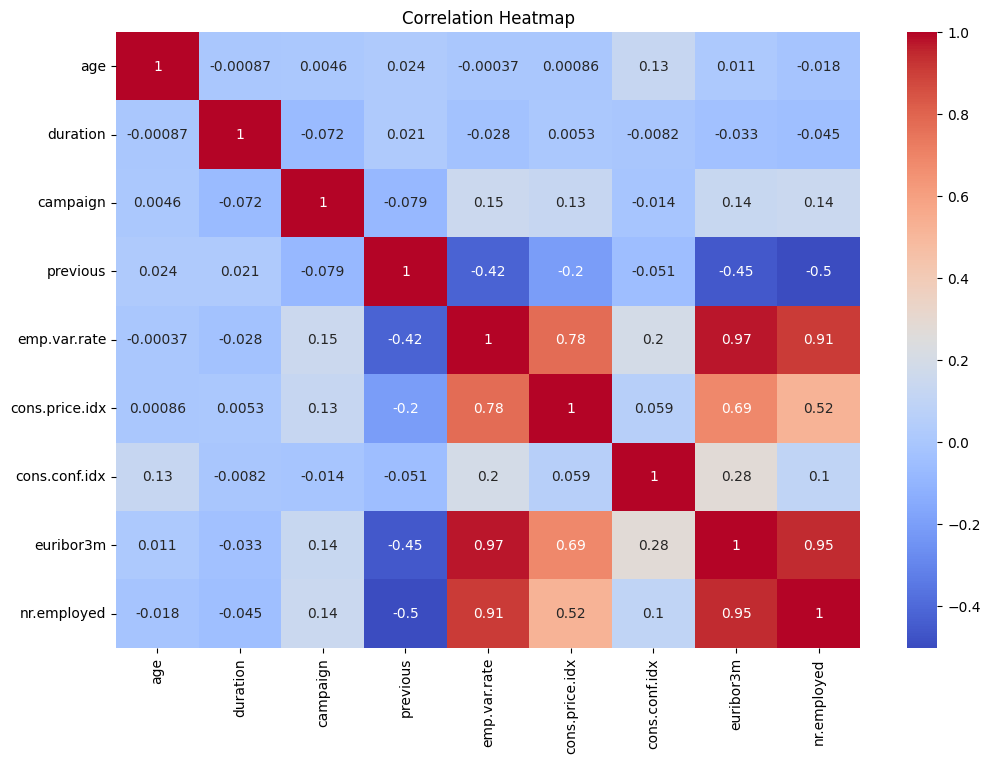

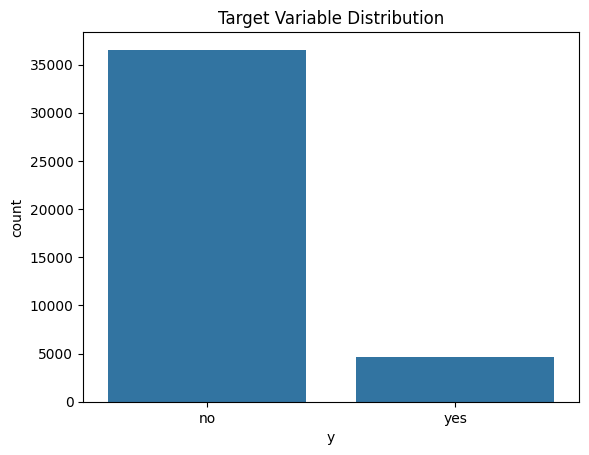

11.265 % of customers subscribed to term deposit
Ratio of customers subscribed to term deposit:  0.126956331399803


In [31]:
# Correlation heatmap for numerical features
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Explore relationship between target and some features
sns.countplot(x='y', data=df)
plt.title('Target Variable Distribution')
plt.show()

print(round(df['y'].value_counts().values[1]/ (df['y'].value_counts().values[0]+ df['y'].value_counts().values[1])*100, 3), "% of customers subscribed to term deposit")
print("Ratio of customers subscribed to term deposit: ", df['y'].value_counts().values[1]/df['y'].value_counts().values[0])

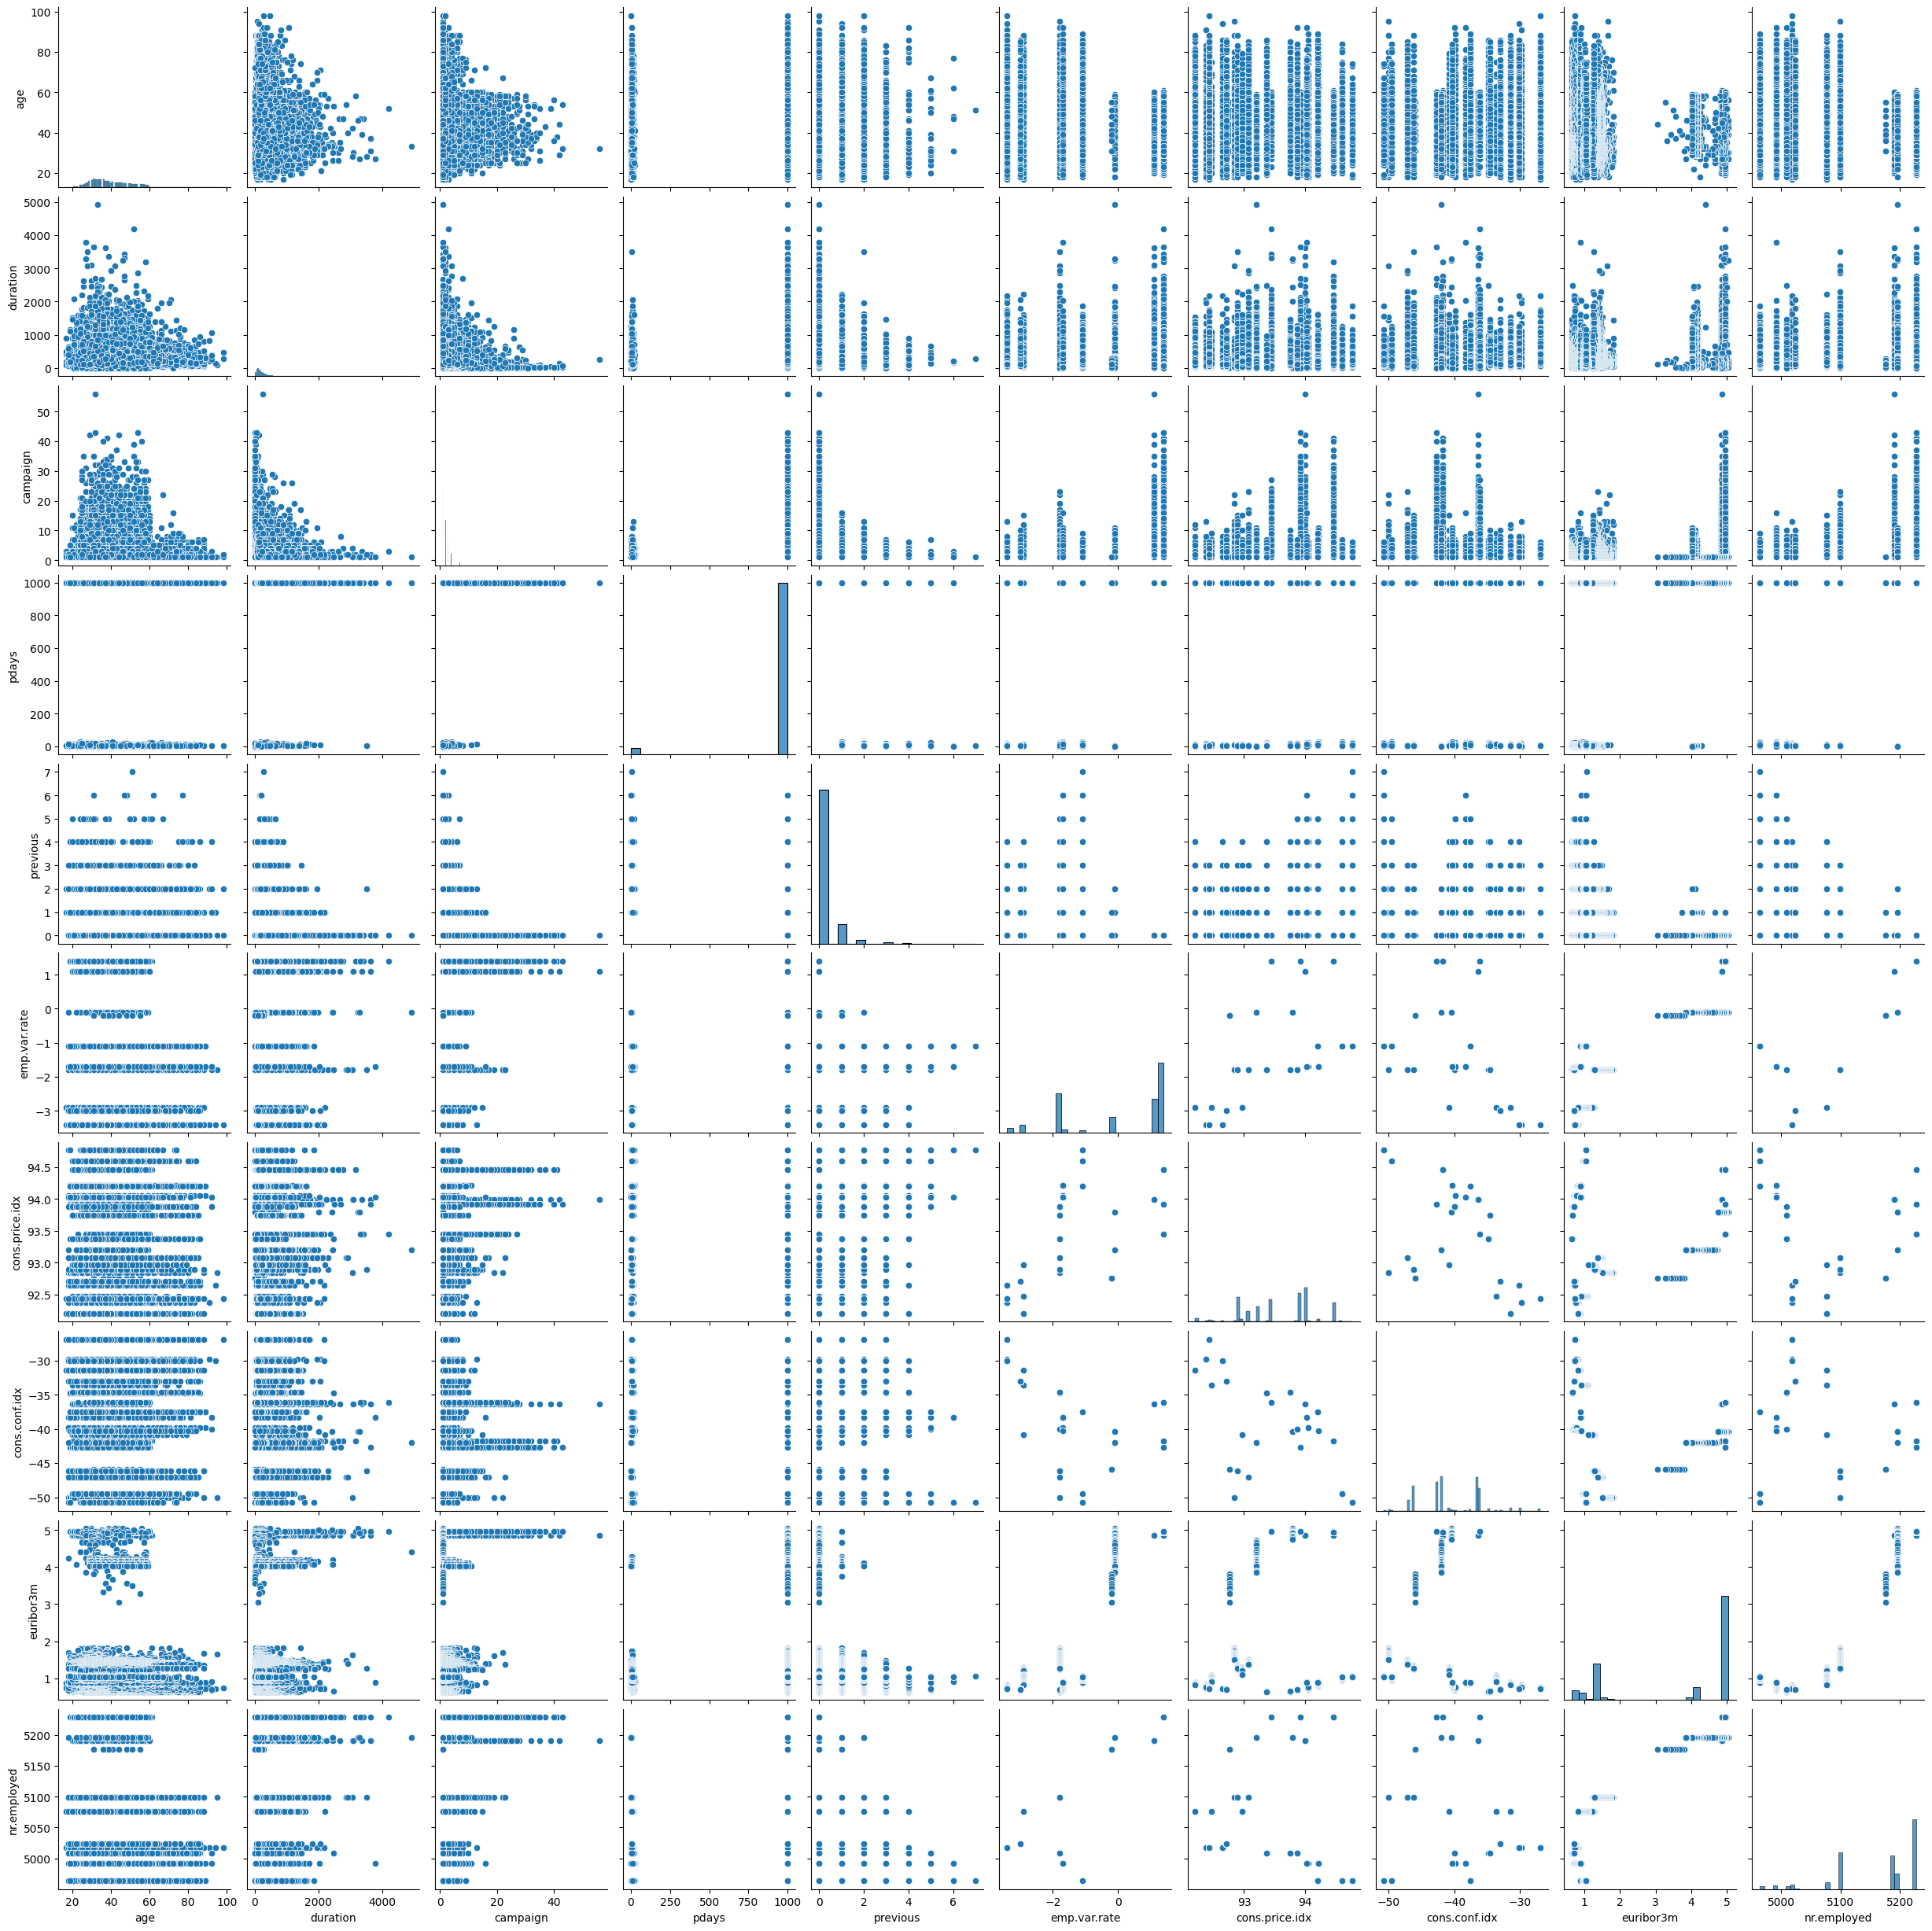

In [96]:
import seaborn as sns

sns.pairplot(df)

# Assumptions of Logistic Regression

### Pre-model Assumptions
#### 1. The response variable must be binary.
#### 2. The observation must be indepedent of each other.
#### 3. There are no extreme outliers.
#### 4. No Multicollinearity.

1 and 3 can be shown using the univariate analysis.

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_num = df.select_dtypes(exclude=['object']).columns
X_num = pd.DataFrame(scaler.fit_transform(df.select_dtypes(exclude=['object'])), 
                        columns=df_num, 
                        index=df.index)
X_num


,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,1.533034,0.010471,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.712460,0.331680
1,1.628993,-0.421501,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.712460,0.331680
2,-0.290186,-0.124520,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.712460,0.331680
3,-0.002309,-0.413787,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.712460,0.331680
4,1.533034,0.187888,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.712460,0.331680
...,...,...,...,...,...,...,...,...,...
41183,3.164336,0.292025,-0.565922,-0.349494,-0.752343,2.058168,-2.224953,-1.495186,-2.815697
41184,0.573445,0.481012,-0.565922,-0.349494,-0.752343,2.058168,-2.224953,-1.495186,-2.815697
41185,1.533034,-0.267225,-0.204909,-0.349494,-0.752343,2.058168,-2.224953,-1.495186,-2.815697
41186,0.381527,0.708569,-0.565922,-0.349494,-0.752343,2.058168,-2.224953,-1.495186,-2.815697


In [33]:
df.select_dtypes(exclude=['object'])

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,261,1,0,1.1,93.994,-36.4,4.857,5191.0
1,57,149,1,0,1.1,93.994,-36.4,4.857,5191.0
2,37,226,1,0,1.1,93.994,-36.4,4.857,5191.0
3,40,151,1,0,1.1,93.994,-36.4,4.857,5191.0
4,56,307,1,0,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...
41183,73,334,1,0,-1.1,94.767,-50.8,1.028,4963.6
41184,46,383,1,0,-1.1,94.767,-50.8,1.028,4963.6
41185,56,189,2,0,-1.1,94.767,-50.8,1.028,4963.6
41186,44,442,1,0,-1.1,94.767,-50.8,1.028,4963.6


In [34]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

df_cat = df.select_dtypes(include=['object']).columns

X = pd.get_dummies(df, columns = df_cat, drop_first = True, dtype = int)
X.drop(columns=df_num, inplace=True)
X[df_num] = X_num
X

,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,...,y_yes,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,0,0,1,0,0,0,0,0,0,0,...,0,1.533034,0.010471,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.712460,0.331680
1,0,0,0,0,0,0,1,0,0,0,...,0,1.628993,-0.421501,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.712460,0.331680
2,0,0,0,0,0,0,1,0,0,0,...,0,-0.290186,-0.124520,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.712460,0.331680
3,0,0,0,0,0,0,0,0,0,0,...,0,-0.002309,-0.413787,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.712460,0.331680
4,0,0,0,0,0,0,1,0,0,0,...,0,1.533034,0.187888,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.712460,0.331680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,0,0,0,0,1,0,0,0,0,0,...,1,3.164336,0.292025,-0.565922,-0.349494,-0.752343,2.058168,-2.224953,-1.495186,-2.815697
41184,1,0,0,0,0,0,0,0,0,0,...,0,0.573445,0.481012,-0.565922,-0.349494,-0.752343,2.058168,-2.224953,-1.495186,-2.815697
41185,0,0,0,0,1,0,0,0,0,0,...,0,1.533034,-0.267225,-0.204909,-0.349494,-0.752343,2.058168,-2.224953,-1.495186,-2.815697
41186,0,0,0,0,0,0,0,0,1,0,...,1,0.381527,0.708569,-0.565922,-0.349494,-0.752343,2.058168,-2.224953,-1.495186,-2.815697


In [35]:
y = X['y_yes']
X = X.drop(columns=['y_yes'])

In [101]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(X)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF_Factor'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif = vif[vif['Feature'] != 'const']

print(vif[vif['VIF_Factor'] > 10])

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


             Feature  VIF_Factor
24   housing_unknown         inf
26      loan_unknown         inf
29         month_aug   10.709644
44           pdays_3   30.213816
47           pdays_6   28.461679
67         pdays_999  115.895938
69  poutcome_success   13.911484
74      emp.var.rate  241.642255
75    cons.price.idx   90.645160
77         euribor3m  200.281315
78       nr.employed  201.720788


In [102]:
X = X.drop(columns = 'emp.var.rate')
X = add_constant(X)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF_Factor'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif = vif[vif['Feature'] != 'const']

print(vif[vif['VIF_Factor'] > 10])

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


             Feature  VIF_Factor
24   housing_unknown         inf
26      loan_unknown         inf
44           pdays_3   30.124274
47           pdays_6   28.363696
67         pdays_999  115.433864
69  poutcome_success   13.902446
74    cons.price.idx   26.122938
76         euribor3m  196.754419
77       nr.employed  126.609456


In [103]:
X = X.drop(columns = 'euribor3m')
X = add_constant(X)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF_Factor'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif = vif[vif['Feature'] != 'const']

print(vif[vif['VIF_Factor'] > 10])

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


             Feature  VIF_Factor
24   housing_unknown         inf
26      loan_unknown         inf
44           pdays_3   30.122924
47           pdays_6   28.359650
67         pdays_999  115.428427
69  poutcome_success   13.900346


In [104]:
X = X.drop(columns = 'loan_unknown')
X = add_constant(X)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF_Factor'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif = vif[vif['Feature'] != 'const']

print(vif[vif['VIF_Factor'] > 10])

             Feature  VIF_Factor
43           pdays_3   30.122924
46           pdays_6   28.359650
66         pdays_999  115.428427
68  poutcome_success   13.900346


In [105]:
X = X.drop(columns = 'pdays_999')
X = add_constant(X)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF_Factor'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif = vif[vif['Feature'] != 'const']

print(vif[vif['VIF_Factor'] > 10])

             Feature  VIF_Factor
67  poutcome_success   11.883918


In [106]:
X = X.drop(columns = 'poutcome_success')
X = add_constant(X)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF_Factor'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif = vif[vif['Feature'] != 'const']

print(vif[vif['VIF_Factor'] > 5])

      Feature  VIF_Factor
28  month_aug    5.370536
70   previous    5.662168


In [107]:
X = X.drop(columns = 'previous')
X = add_constant(X)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF_Factor'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif = vif[vif['Feature'] != 'const']

print(vif[vif['VIF_Factor'] > 5])

      Feature  VIF_Factor
28  month_aug    5.310855


In [108]:
X = X.drop(columns = 'month_aug')
X = add_constant(X)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF_Factor'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif = vif[vif['Feature'] != 'const']

In [109]:
print(vif)

             Feature  VIF_Factor
1    job_blue-collar    2.418475
2   job_entrepreneur    1.138648
3      job_housemaid    1.185876
4     job_management    1.246680
5        job_retired    1.491750
..               ...         ...
67          duration    1.015646
68          campaign    1.043537
69    cons.price.idx    2.931018
70     cons.conf.idx    1.592217
71       nr.employed    2.781633

[71 rows x 2 columns]


In [110]:
X.columns

Index(['const', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'marital_unknown',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown', 'default_unknown',
       'default_yes', 'housing_unknown', 'housing_yes', 'loan_yes',
       'contact_telephone', 'month_dec', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon',
       'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'pdays_1',
       'pdays_2', 'pdays_3', 'pdays_4', 'pdays_5', 'pdays_6', 'pdays_7',
       'pdays_8', 'pdays_9', 'pdays_10', 'pdays_11', 'pdays_12', 'pdays_13',
       'pdays_14', 'pdays_15', 'pdays_16', 'pd

In [111]:
from sklearn.model_selection import train_test_split

X = X.drop(columns='const')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size  = 0.2)

In [112]:
import numpy as np
import pandas as pd

# Check rank vs. number of features
print("Matrix Rank:", np.linalg.matrix_rank(X_train))
print("Shape of X_train:", X_train.shape)  # (n_samples, n_features)

# If rank < number of features → linear dependency exists
X_train.columns

Matrix Rank: 71
Shape of X_train: (32950, 71)


Index(['job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'marital_unknown',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown', 'default_unknown',
       'default_yes', 'housing_unknown', 'housing_yes', 'loan_yes',
       'contact_telephone', 'month_dec', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon',
       'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'pdays_1',
       'pdays_2', 'pdays_3', 'pdays_4', 'pdays_5', 'pdays_6', 'pdays_7',
       'pdays_8', 'pdays_9', 'pdays_10', 'pdays_11', 'pdays_12', 'pdays_13',
       'pdays_14', 'pdays_15', 'pdays_16', 'pdays_17', 

In [113]:
low_variance = X_train.loc[:, X_train.var() < 1e-5]
print("Near-constant columns:", low_variance.columns.tolist())
X_train = X_train.drop(columns=low_variance.columns)

# Check rank vs. number of features
print("Matrix Rank:", np.linalg.matrix_rank(X_train))
print("Shape of X_train:", X_train.shape)  # (n_samples, n_features)

# If rank < number of features → linear dependency exists
X_train.columns


Near-constant columns: []
Matrix Rank: 71
Shape of X_train: (32950, 71)


Index(['job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'marital_unknown',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown', 'default_unknown',
       'default_yes', 'housing_unknown', 'housing_yes', 'loan_yes',
       'contact_telephone', 'month_dec', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon',
       'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'pdays_1',
       'pdays_2', 'pdays_3', 'pdays_4', 'pdays_5', 'pdays_6', 'pdays_7',
       'pdays_8', 'pdays_9', 'pdays_10', 'pdays_11', 'pdays_12', 'pdays_13',
       'pdays_14', 'pdays_15', 'pdays_16', 'pdays_17', 

## Fitting Model

In [114]:
import statsmodels.api as sm

logistic = sm.Logit(y_train, X_train)
result = logistic.fit(method='nm', maxiter=500)
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                  y_yes   No. Observations:                32950
Model:                          Logit   Df Residuals:                    32879
Method:                           MLE   Df Model:                           70
Date:                Mon, 28 Jul 2025   Pseudo R-squ.:                 -0.9519
Time:                        11:13:43   Log-Likelihood:                -22814.
converged:                      False   LL-Null:                       -11688.
Covariance Type:            nonrobust   LLR p-value:                     1.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
job_blue-collar               -9.803e-05      0.038     -0.003      0.998      -0.075       0.075
job_entrepreneur               7.514e-05      0.063      0.001      0.999 

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\optimizer.py:748: RuntimeWarning: Maximum number of iterations has been exceeded.
  retvals = optimize.fmin(f, start_params, args=fargs, xtol=xtol,
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [115]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

def box_tidwell_test(X, y):
    """
    Perform Box-Tidwell test for each continuous predictor in X against the binary target y.
    
    Parameters:
    - X: pd.DataFrame of continuous predictors
    - y: pd.Series or 1D np.array of binary target (0/1)
    
    Returns:
    - DataFrame with coefficients, standard errors, z-stats, p-values for interaction terms
    """
    results = []

    for col in X.columns:
        x = X[col]
        
        # Prevent zero or negative values for log(x)
        if any(x <= 0):
            print(f"Skipping {col} (contains zero or negative values)")
            continue
        
        x_log = x * np.log(x)
        df_temp = X.copy()
        df_temp[col + "_log"] = x_log

        # Add constant for intercept
        df_temp = sm.add_constant(df_temp)

        # Fit logistic regression
        model = sm.Logit(y, df_temp)
        result = model.fit(disp=False)

        # Extract coefficient and p-value for interaction term
        coef = result.params[col + "_log"]
        se = result.bse[col + "_log"]
        z = coef / se
        p_value = result.pvalues[col + "_log"]

        results.append({
            'Variable': col,
            'Interaction Term': col + "_log",
            'Coef': coef,
            'SE': se,
            'Z': z,
            'p-value': p_value
        })

    return pd.DataFrame(results)


X_train_num = X[['age', 'duration', 'campaign', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']]
bt_results = box_tidwell_test(X_train_num, y)
print(bt_results)

Skipping age (contains zero or negative values)
Skipping duration (contains zero or negative values)
Skipping campaign (contains zero or negative values)
Skipping cons.price.idx (contains zero or negative values)
Skipping cons.conf.idx (contains zero or negative values)
Skipping nr.employed (contains zero or negative values)
Empty DataFrame
Columns: []
Index: []


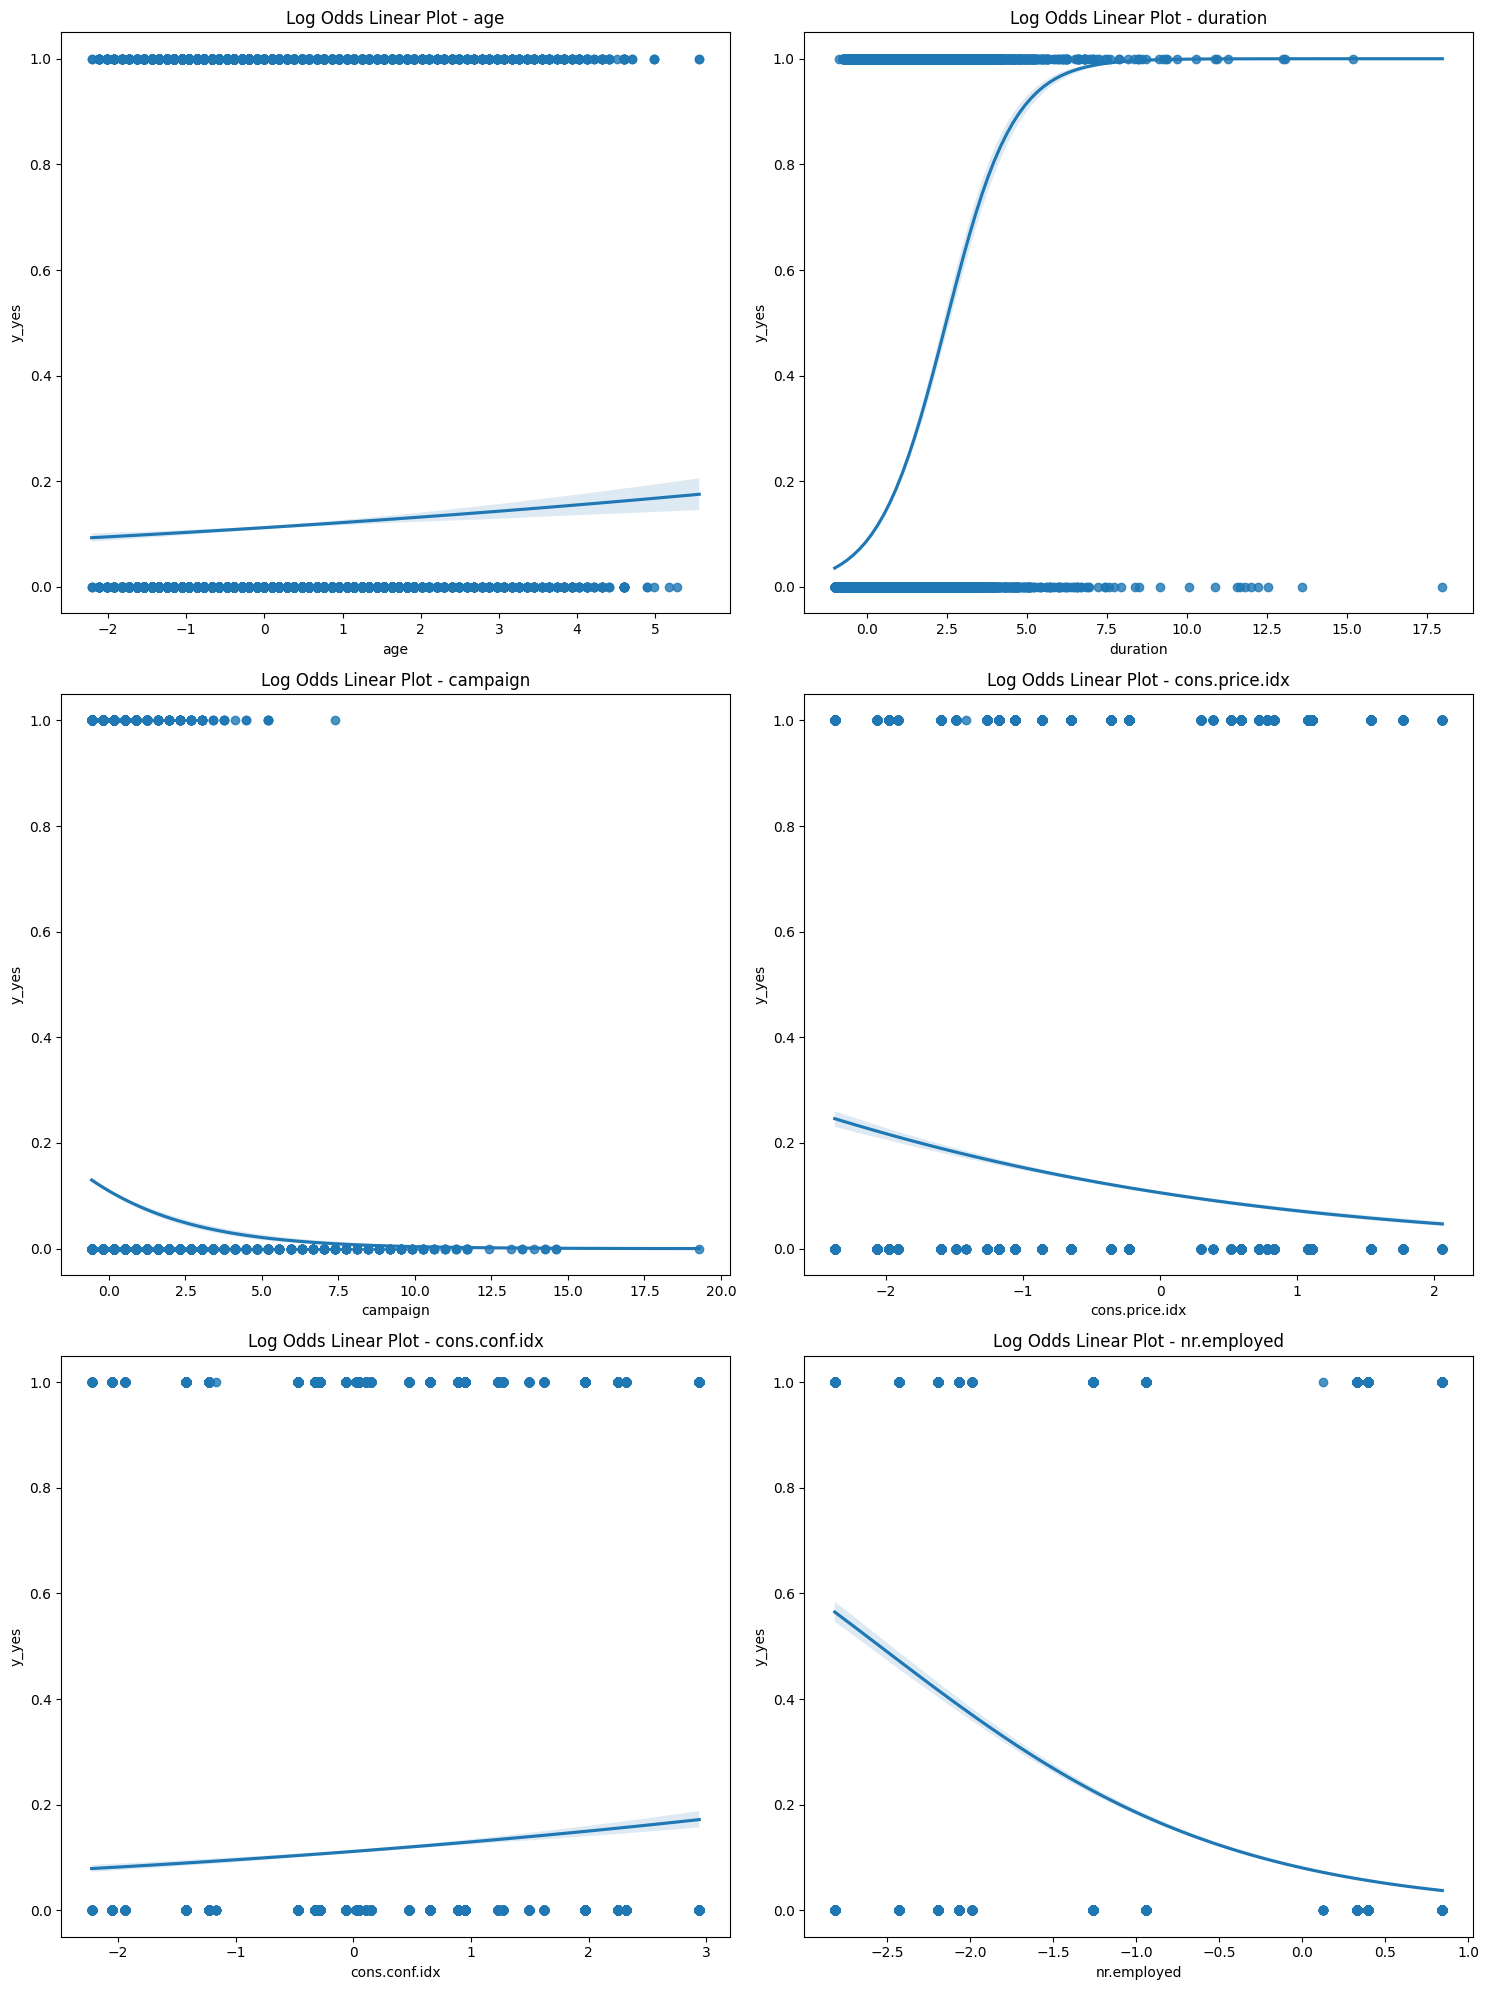

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['age', 'duration', 'campaign', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']

plt.figure(figsize=(15, 20))  # Adjust size as needed

for i, feature in enumerate(features):
    plt.subplot(3, 2, i + 1)
    sns.regplot(x=X_train_num[feature], y=y, logistic=True)
    plt.title(f'Log Odds Linear Plot - {feature}')

plt.tight_layout()
plt.show()


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.ensemble import EasyEnsembleClassifier


In [37]:
df2 = df1

In [38]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  object 
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [39]:
df_cat = df.select_dtypes(include=['object']).columns
df_num = df.select_dtypes(exclude=['object']).columns

df2 = pd.get_dummies(df, columns = df_cat, drop_first = True, dtype = int)
df2.head(5)

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,pdays_20,pdays_21,pdays_22,pdays_25,pdays_26,pdays_27,pdays_999,poutcome_nonexistent,poutcome_success,y_yes
0,56,261,1,0,1.1,93.994,-36.4,4.857,5191.0,0,...,0,0,0,0,0,0,1,1,0,0
1,57,149,1,0,1.1,93.994,-36.4,4.857,5191.0,0,...,0,0,0,0,0,0,1,1,0,0
2,37,226,1,0,1.1,93.994,-36.4,4.857,5191.0,0,...,0,0,0,0,0,0,1,1,0,0
3,40,151,1,0,1.1,93.994,-36.4,4.857,5191.0,0,...,0,0,0,0,0,0,1,1,0,0
4,56,307,1,0,1.1,93.994,-36.4,4.857,5191.0,0,...,0,0,0,0,0,0,1,1,0,0


In [40]:
X2 = df2.drop(columns='y_yes')
y2 = df2['y_yes']

In [41]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size = 0.2)

In [42]:
scaler = StandardScaler()
X2_train[df_num] = scaler.fit_transform(X2_train[df_num])
X2_test[df_num] = scaler.transform(X2_test[df_num])
X2_train.head(5)

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,pdays_19,pdays_20,pdays_21,pdays_22,pdays_25,pdays_26,pdays_27,pdays_999,poutcome_nonexistent,poutcome_success
39485,1.631467,1.293995,0.159417,1.657390,-1.203464,0.295353,1.276928,-1.723335,-2.192824,0,...,0,0,0,0,0,0,0,1,0,0
30038,-1.439991,-0.578127,0.159417,1.657390,-1.203464,-0.869175,-1.429609,-1.282821,-0.941897,0,...,0,0,0,0,0,0,0,1,0,0
26125,-0.864092,1.786052,-0.203045,-0.347861,-0.119225,-0.653202,-0.325342,0.284668,0.396208,0,...,0,0,0,0,0,0,0,1,1,0
17058,-0.768109,-0.774180,0.521879,-0.347861,0.837457,0.587349,-0.476908,0.770792,0.843165,0,...,0,0,0,0,0,0,0,1,1,0
13760,0.095738,-0.612724,-0.565506,-0.347861,0.837457,0.587349,-0.476908,0.771369,0.843165,0,...,0,0,0,0,0,0,0,1,1,0


In [43]:
lr1 = LogisticRegression()

In [44]:
lr = EasyEnsembleClassifier(
    estimator=LogisticRegression(),
    n_estimators=10,
    warm_start=True,
    random_state=42)
lr.fit(X2_train, y2_train)

y2_pred_lr = lr.predict(X2_test)
y2_tain_lr = lr.predict(X2_train)

In [158]:
print("Model: Logistic Regression (EasyEnsemble('n_estimators': 10))\n")
print(confusion_matrix(y2_test, y2_pred_lr))
print("Accuracy: ", accuracy_score(y2_test, y2_pred_lr))
print("Precision: ", precision_score(y2_test, y2_pred_lr))
print("Recall: ", recall_score(y2_test, y2_pred_lr))
print("F1 Score: ", f1_score(y2_test, y2_pred_lr))
print("ROC-AUC Score: ", roc_auc_score(y2_test, y2_pred_lr))

Model: Logistic Regression (EasyEnsemble('n_estimators': 10))

[[6260 1022]
 [ 126  830]]
Accuracy:  0.8606457878125758
Precision:  0.4481641468682505
Recall:  0.8682008368200836
F1 Score:  0.5911680911680912
ROC-AUC Score:  0.863927389022511


In [46]:
# Recall = Tp/(TP+FN)
853/(853+123)

0.8739754098360656

In [47]:
print(confusion_matrix(y2_train, y2_tain_lr))

[[25061  4205]
 [  397  3287]]


In [48]:
3254/(410+3254)

0.8881004366812227

#### We found that the data is not linearly related. So using Logistic Regression is not helpful for us. So, we try some algorithms which are flexible for non-linear data.

### SVM - Support Vector Machine

In [49]:
from sklearn.svm import SVC
from imblearn.ensemble import EasyEnsembleClassifier
import optuna

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [50]:
svc = EasyEnsembleClassifier(
    estimator=SVC(C=10, kernel='rbf', class_weight='balanced'),
    n_estimators=10,
    warm_start=True,
    random_state=42)

In [51]:
svc.fit(X2_train, y2_train)

y2_pred_svc = svc.predict(X2_test)

In [52]:
print(confusion_matrix(y2_test, y2_pred_svc))
print("Accuracy: ", accuracy_score(y2_test, y2_pred_svc))
print("Precision: ", precision_score(y2_test, y2_pred_svc))
print("Recall: ", recall_score(y2_test, y2_pred_svc))
print("F1 Score: ", f1_score(y2_test, y2_pred_svc))
print("ROC-AUC Score: ", roc_auc_score(y2_test, y2_pred_svc))

[[6130 1152]
 [  80  876]]
Accuracy:  0.8504491381403253
Precision:  0.4319526627218935
Recall:  0.9163179916317992
F1 Score:  0.5871313672922251
ROC-AUC Score:  0.8790598472303461


### Using Optuna

In [53]:
def objective_svc(trial):

    C = trial.suggest_float("C", 0.001, 100)
    kernel = trial.suggest_categorical("kernel", ['poly', 'rbf', 'linear'])
    degree = trial.suggest_int('degree', 2, 10)
    class_weight = trial.suggest_categorical("class_weight", [None, 'balanced'])

    n_estimators = trial.suggest_int('n_estimators', 10, 100)
    warm_start = trial.suggest_categorical('warm_start', [True, False])

    model = EasyEnsembleClassifier(
        estimator=SVC(
            C=C,
            kernel=kernel,
            degree=degree,
            class_weight=class_weight),
        n_estimators=n_estimators,
        warm_start=warm_start,
    )

    score = cross_validate(model, X2_train, y2_train, cv=5, scoring=['recall_macro', 'f1_macro', 'precision_macro'])
    return score['test_recall_macro'].mean()

In [55]:
study_svc = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())
study_svc.optimize(objective_svc, n_trials=20)

print(f'Best trial accuracy: {study_svc.best_trial.value}')
print(f'Best hyperparameters: {study_svc.best_trial.params}')

[I 2025-07-29 02:14:01,482] A new study created in memory with name: no-name-d4c33fe2-31f6-4145-8cd5-ce03bebec6de
[I 2025-07-29 02:20:43,420] Trial 0 finished with value: 0.8709054332050495 and parameters: {'C': 72.12188816763084, 'kernel': 'rbf', 'degree': 5, 'class_weight': None, 'n_estimators': 28, 'warm_start': True}. Best is trial 0 with value: 0.8709054332050495.
[I 2025-07-29 03:22:17,641] Trial 1 finished with value: 0.8747316478480662 and parameters: {'C': 65.72949284573018, 'kernel': 'linear', 'degree': 7, 'class_weight': 'balanced', 'n_estimators': 66, 'warm_start': True}. Best is trial 1 with value: 0.8747316478480662.
[I 2025-07-29 03:32:41,952] Trial 2 finished with value: 0.8752096458602174 and parameters: {'C': 30.31614544481506, 'kernel': 'linear', 'degree': 7, 'class_weight': 'balanced', 'n_estimators': 20, 'warm_start': False}. Best is trial 2 with value: 0.8752096458602174.
[I 2025-07-29 03:39:09,128] Trial 3 finished with value: 0.8776810836605244 and parameters: {

Best trial accuracy: 0.882414845520581
Best hyperparameters: {'C': 7.757402277028851, 'kernel': 'rbf', 'degree': 10, 'class_weight': None, 'n_estimators': 99, 'warm_start': False}


In [58]:
study_svc.best_params

{'C': 7.757402277028851,
 'kernel': 'rbf',
 'degree': 10,
 'class_weight': None,
 'n_estimators': 99,
 'warm_start': False}

In [59]:
svc_params_ = study_svc.best_params

params_svc = {
    "C": svc_params_["C"],
    "kernel": svc_params_["kernel"],
    "degree": svc_params_["degree"],
    "class_weight": svc_params_["class_weight"]
} 
ensemble_svc_prams = {
    'n_estimators': svc_params_['n_estimators'],
    'warm_start': svc_params_['warm_start'],
    'random_state': 42
}
    
best_model_svc = EasyEnsembleClassifier(estimator=SVC(**params_svc), **ensemble_svc_prams)
best_model_svc.fit(X2_train, y2_train)
y2_pred_optuna_svc = best_model_svc.predict(X2_test)

In [160]:
print("Model: SVM (EasyEnsemble('n_estimators': 99),\n'C': 7.757402277028851, 'kernel': 'rbf', 'degree': 10,\n'class_weight': None)\n")
print(confusion_matrix(y2_test, y2_pred_optuna_svc))
print("Accuracy: ", accuracy_score(y2_test, y2_pred_optuna_svc))
print("Precision: ", precision_score(y2_test, y2_pred_optuna_svc))
print("Recall: ", recall_score(y2_test, y2_pred_optuna_svc))
print("F1 Score: ", f1_score(y2_test, y2_pred_optuna_svc))
print("ROC-AUC Score: ", f1_score(y2_test, y2_pred_optuna_svc))

Model: SVM (EasyEnsemble('n_estimators': 99),
'C': 7.757402277028851, 'kernel': 'rbf', 'degree': 10,
'class_weight': None)

[[6079 1203]
 [  72  884]]
Accuracy:  0.8452294246176256
Precision:  0.4235745088643987
Recall:  0.9246861924686193
F1 Score:  0.5810055865921788
ROC-AUC Score:  0.5810055865921788


## Decision Tree
#### We use imbalanced ensemble methods to balance the data and use Random Forest Classifier

In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import optuna

In [65]:
parameters_dt = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 15], 
    'class_weight': [None, 'balanced']
}

In [66]:
search_dt = GridSearchCV(DecisionTreeClassifier(), parameters_dt, cv=5)

In [67]:
search_dt.fit(X2_train, y2_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'class_weight': [None, 'balanced'],
                         'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [5, 10, 15, 20],
                         'min_samples_split': [2, 5, 10, 15],
                         'splitter': ['best', 'random']})

In [69]:
dt_params_ = search_dt.best_params_

In [70]:
clf2 = DecisionTreeClassifier(**dt_params_)

In [71]:
clf2.fit(X2_train, y2_train)

DecisionTreeClassifier(max_depth=5)

In [72]:
pd.Series(clf2.predict(X2_test)).value_counts()

0    7480
1     758
Name: count, dtype: int64

In [73]:
y2_predict_dt = clf2.predict(X2_test)

In [74]:
print(confusion_matrix(y2_test, y2_predict_dt))
print("Accuracy: ", accuracy_score(y2_test, y2_predict_dt))
print("Precision: ", precision_score(y2_test, y2_predict_dt))
print("Recall: ", recall_score(y2_test, y2_predict_dt))
print("F1 Score: ", f1_score(y2_test, y2_predict_dt))
print("ROC-AUC Score: ", f1_score(y2_test, y2_predict_dt))

[[7029  253]
 [ 451  505]]
Accuracy:  0.9145423646516144
Precision:  0.6662269129287599
Recall:  0.5282426778242678
F1 Score:  0.5892648774795799
ROC-AUC Score:  0.5892648774795799


#### Using Optuna

In [79]:
def objective_dt(trial):

    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss'])
    splitter = trial.suggest_categorical('splitter', ['best', 'random'])
    max_depth = trial.suggest_int('max_depth', 2, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 15)
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])

    n_estimators = trial.suggest_int('n_estimators', 10, 100)
    warm_start = trial.suggest_categorical('warm_start', [True, False])

    model = EasyEnsembleClassifier(
        estimator=DecisionTreeClassifier(
            criterion=criterion,
            splitter=splitter,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            class_weight=class_weight,
            random_state=42
        ),
        n_estimators=n_estimators,
        warm_start=warm_start,
        random_state=42)

    score = cross_validate(model, X2_train, y2_train, cv=5, scoring=['recall_macro', 'f1_macro', 'precision_macro'])
    return score['test_recall_macro'].mean()

In [80]:
study_dt = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())
study_dt.optimize(objective_dt, n_trials=100)

print(f'Best trial accuracy: {study_dt.best_trial.value}')
print(f'Best hyperparameters: {study_dt.best_trial.params}')

[I 2025-07-29 12:43:58,976] A new study created in memory with name: no-name-5f9fd467-2ed7-45ec-899a-39f8b91f0d4f
[I 2025-07-29 12:44:16,270] Trial 0 finished with value: 0.8889877587933255 and parameters: {'criterion': 'log_loss', 'splitter': 'best', 'max_depth': 9, 'min_samples_split': 15, 'class_weight': None, 'n_estimators': 97, 'warm_start': False}. Best is trial 0 with value: 0.8889877587933255.
[I 2025-07-29 12:44:25,441] Trial 1 finished with value: 0.8762931602503314 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 6, 'min_samples_split': 11, 'class_weight': None, 'n_estimators': 81, 'warm_start': True}. Best is trial 0 with value: 0.8889877587933255.
[I 2025-07-29 12:44:34,000] Trial 2 finished with value: 0.8676686815013024 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 5, 'min_samples_split': 7, 'class_weight': None, 'n_estimators': 82, 'warm_start': False}. Best is trial 0 with value: 0.8889877587933255.
[I 2025-07-2

Best trial accuracy: 0.892310952010325
Best hyperparameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 10, 'min_samples_split': 3, 'class_weight': 'balanced', 'n_estimators': 49, 'warm_start': False}


In [81]:
dt_optuna_params = study_dt.best_params

params_dt = {
    'criterion': dt_optuna_params['criterion'],
    'splitter': dt_optuna_params['splitter'],
    'max_depth': dt_optuna_params['max_depth'],
    'min_samples_split': dt_optuna_params['min_samples_split'],
    'class_weight': dt_optuna_params['class_weight']
}

ensemble_dt_params = {
    'n_estimators': dt_optuna_params['n_estimators'],
    'warm_start': dt_optuna_params['warm_start'],
}

best_model_dt = EasyEnsembleClassifier(estimator=DecisionTreeClassifier(**params_dt, random_state=42), **ensemble_dt_params, random_state=42)
best_model_dt.fit(X2_train, y2_train)
y2_pred_dt_optuna = best_model_dt.predict(X2_test)

In [122]:
print("Model: DecisionTree (EasyEnsemble('n_estimators': 49), 'criterion': 'entropy',\n'splitter': 'best', 'max_depth': 10, 'min_samples_split': 3,\n'class_weight': 'balanced)\n")
print(confusion_matrix(y2_test, y2_pred_dt_optuna))
print("Accuracy: ", accuracy_score(y2_test, y2_pred_dt_optuna))
print("Precision: ", precision_score(y2_test, y2_pred_dt_optuna))
print("Recall: ", recall_score(y2_test, y2_pred_dt_optuna))
print("F1 Score: ", f1_score(y2_test, y2_pred_dt_optuna))
print("ROC-AUC Score: ", roc_auc_score(y2_test, y2_pred_dt_optuna))

Model: DecisionTree (EasyEnsemble('n_estimators': 49), 'criterion': 'entropy',
'splitter': 'best', 'max_depth': 10, 'min_samples_split': 3,
'class_weight': 'balanced)

[[6187 1095]
 [  58  898]]
Accuracy:  0.8600388443797038
Precision:  0.4505770195684897
Recall:  0.9393305439330544
F1 Score:  0.60902000678196
ROC-AUC Score:  0.8944798833370298


## Random Forest
#### We use imbalanced ensemble methods to balance the data and use Random Forest Classifier

In [ ]:
y2_train.value_counts()

y_yes
0    29200
1     3750
Name: count, dtype: int64

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators= 200, bootstrap=True, oob_score=True, max_samples=0.7, class_weight='balanced')
rf_classifier.fit(X2_train, y2_train)
pd.Series(rf_classifier.predict(X2_test)).value_counts()
y2_predict_rf = rf_classifier.predict(X2_test)
print("The OOB Score: ", rf_classifier.oob_score_, "\n")
print(confusion_matrix(y2_test, y2_predict_rf))
print("Accuracy: ", accuracy_score(y2_test, y2_predict_rf))
print("Precision: ", precision_score(y2_test, y2_predict_rf))
print("Recall: ", recall_score(y2_test, y2_predict_rf))
print("F1 Score: ", f1_score(y2_test, y2_predict_rf))
print("ROC-AUC Score: ", roc_auc_score(y2_test, y2_predict_rf))

The OOB Score:  0.9125948406676783 

[[7175  173]
 [ 548  342]]
Accuracy:  0.9124787569798495
Precision:  0.6640776699029126
Recall:  0.3842696629213483
F1 Score:  0.48683274021352313


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators= 200, bootstrap=True, oob_score=True, class_weight={0: 1, 1: 5}, max_samples=0.7)
rf_classifier.fit(X2_train, y2_train)
pd.Series(rf_classifier.predict(X2_test)).value_counts()
y2_predict_rf = rf_classifier.predict(X2_test)
print("The OOB Score: ", rf_classifier.oob_score_, "\n")
print(confusion_matrix(y2_test, y2_predict_rf))
print("Accuracy: ", accuracy_score(y2_test, y2_predict_rf))
print("Precision: ", precision_score(y2_test, y2_predict_rf))
print("Recall: ", recall_score(y2_test, y2_predict_rf))
print("F1 Score: ", f1_score(y2_test, y2_predict_rf))
print("ROC-AUC Score: ", roc_auc_score(y2_test, y2_predict_rf))

The OOB Score:  0.9115022761760243 

[[7158  190]
 [ 538  352]]
Accuracy:  0.9116290361738286
Precision:  0.6494464944649446
Recall:  0.3955056179775281
F1 Score:  0.49162011173184356


In [100]:
from imblearn.ensemble import BalancedRandomForestClassifier

bal_rf_classifier = BalancedRandomForestClassifier(n_estimators= 200, bootstrap=True, oob_score=True, max_samples=0.7)
bal_rf_classifier.fit(X2_train, y2_train)
pd.Series(bal_rf_classifier.predict(X2_test)).value_counts()
y2_predict_bal_rf = bal_rf_classifier.predict(X2_test)
print("The OOB Score: ", bal_rf_classifier.oob_score_, "\n")
print(confusion_matrix(y2_test, y2_predict_bal_rf))
print("Accuracy: ", accuracy_score(y2_test, y2_predict_bal_rf))
print("Precision: ", precision_score(y2_test, y2_predict_bal_rf))
print("Recall: ", recall_score(y2_test, y2_predict_bal_rf))
print("F1 Score: ", f1_score(y2_test, y2_predict_bal_rf))
print("ROC-AUC Score: ", roc_auc_score(y2_test, y2_predict_bal_rf))

The OOB Score:  0.9451593323216996 

[[6290  992]
 [  83  873]]
Accuracy:  0.8695071619325079
Precision:  0.46809651474530833
Recall:  0.9131799163179917
F1 Score:  0.6189294576391351
ROC-AUC Score:  0.8884768024325471


#### Using Optuna

In [105]:
def objective_rf(trial):

    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 2, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 15)
    max_features = trial.suggest_categorical('max_features', [None, 'sqrt', 'log2'])
    min_impurity_decrease = trial.suggest_float('min_impurity_decrease', 0.0, 1.0)
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])

    model = BalancedRandomForestClassifier(
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        min_impurity_decrease=min_impurity_decrease,
        class_weight=class_weight,
        bootstrap=bootstrap,
        random_state=42
    )

    score = cross_validate(model, X2_train, y2_train, cv=5, scoring=['recall_macro', 'f1_macro'])
    return score['test_recall_macro'].mean()

In [106]:
study_Bal_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())
study_Bal_rf.optimize(objective_rf, n_trials=50)

print(f'Best trial accuracy: {study_Bal_rf.best_trial.value}')
print(f'Best hyperparameters: {study_Bal_rf.best_trial.params}')

[I 2025-07-31 00:37:34,591] A new study created in memory with name: no-name-4703929c-38c4-4979-a970-af3acd4f7f51
[I 2025-07-31 00:37:37,589] Trial 0 finished with value: 0.5 and parameters: {'n_estimators': 103, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 14, 'max_features': 'log2', 'min_impurity_decrease': 0.9256001880103958, 'class_weight': None, 'bootstrap': False}. Best is trial 0 with value: 0.5.
[I 2025-07-31 00:37:42,948] Trial 1 finished with value: 0.5 and parameters: {'n_estimators': 182, 'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 11, 'max_features': 'log2', 'min_impurity_decrease': 0.8433336269920804, 'class_weight': 'balanced', 'bootstrap': True}. Best is trial 0 with value: 0.5.
[I 2025-07-31 00:37:46,821] Trial 2 finished with value: 0.8109086989566882 and parameters: {'n_estimators': 63, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10, 'max_features': None, 'min_impurity_decrease': 0.1189742732250686, 'class_weight': None

Best trial accuracy: 0.8866206330811469
Best hyperparameters: {'n_estimators': 88, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 10, 'max_features': None, 'min_impurity_decrease': 0.00022412074054547777, 'class_weight': None, 'bootstrap': False}


In [107]:
best_model_Bal_rf = BalancedRandomForestClassifier(**study_Bal_rf.best_params, random_state=42)
best_model_Bal_rf.fit(X2_train, y2_train)
y2_pred_rf_optuna = best_model_Bal_rf.predict(X2_test)

In [120]:
print("Model: BalancedRandomForest('n_estimators': 88, 'criterion': 'entropy',\n'max_depth': 7, 'min_samples_split': 10, 'max_features': None, \n'min_impurity_decrease': 0.00022, 'class_weight': None, 'bootstrap': False)\n")
print(confusion_matrix(y2_test, y2_pred_rf_optuna))
print("Accuracy: ", accuracy_score(y2_test, y2_pred_rf_optuna))
print("Precision: ", precision_score(y2_test, y2_pred_rf_optuna))
print("Recall: ", recall_score(y2_test, y2_pred_rf_optuna))
print("F1 Score: ", f1_score(y2_test, y2_pred_rf_optuna))
print("ROC-AUC Score: ", roc_auc_score(y2_test, y2_pred_rf_optuna))

Model: BalancedRandomForest('n_estimators': 88, 'criterion': 'entropy',
'max_depth': 7, 'min_samples_split': 10, 'max_features': None, 
'min_impurity_decrease': 0.00022, 'class_weight': None, 'bootstrap': False)

[[6169 1113]
 [  68  888]]
Accuracy:  0.8566399611556202
Precision:  0.44377811094452774
Recall:  0.9288702928870293
F1 Score:  0.6006087250591816
ROC-AUC Score:  0.8880138336173679


## Boosting Algorithms
### AdaBoost

In [ ]:
from imblearn.ensemble import EasyEnsembleClassifier

In [ ]:
ada_clf = EasyEnsembleClassifier()
ada_clf.fit(X2_train, y2_train)
y2_pred_ada = ada_clf.predict(X2_test)
print(confusion_matrix(y2_test, y2_pred_ada))
print("Accuracy: ", accuracy_score(y2_test, y2_pred_ada))
print("Precision: ", precision_score(y2_test, y2_pred_ada))
print("Recall: ", recall_score(y2_test, y2_pred_ada))
print("F1 Score: ", f1_score(y2_test, y2_pred_ada))
print("ROC-AUC Score: ", roc_auc_score(y2_test, y2_pred_ada))

[[6294 1054]
 [  98  792]]
Accuracy:  0.8601602330662782
Precision:  0.42903575297941493
Recall:  0.8898876404494382
F1 Score:  0.5789473684210527


#### Using Optuna

In [110]:
def objective_adaboost(trial):

    n_estimators = trial.suggest_int('n_estimators', 10, 100)
    warm_start = trial.suggest_categorical('warm_start', [True, False])


    model = ada_clf = EasyEnsembleClassifier(
        n_estimators=n_estimators,
        warm_start=warm_start,
        random_state=42
    )

    score = cross_validate(model, X2_train, y2_train, cv=5, scoring=['recall_macro', 'f1_macro', 'precision_macro'])
    return score['test_recall_macro'].mean()

In [ ]:
study_adaboost = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())
study_adaboost.optimize(objective_adaboost, n_trials=50)

print(f'Best trial accuracy: {study_adaboost.best_trial.value}')
print(f'Best hyperparameters: {study_adaboost.best_trial.params}')

[I 2025-07-25 20:17:34,200] A new study created in memory with name: no-name-1a6b91f2-2654-4392-b8b4-2ba273846c51
[I 2025-07-25 20:17:56,088] Trial 0 finished with value: 0.8705445205479452 and parameters: {'n_estimators': 12, 'warm_start': False}. Best is trial 0 with value: 0.8705445205479452.
[I 2025-07-25 20:19:34,065] Trial 1 finished with value: 0.870413698630137 and parameters: {'n_estimators': 55, 'warm_start': False}. Best is trial 0 with value: 0.8705445205479452.
[I 2025-07-25 20:20:43,416] Trial 2 finished with value: 0.8707452054794519 and parameters: {'n_estimators': 39, 'warm_start': True}. Best is trial 2 with value: 0.8707452054794519.
[I 2025-07-25 20:23:27,132] Trial 3 finished with value: 0.8708748858447489 and parameters: {'n_estimators': 91, 'warm_start': False}. Best is trial 3 with value: 0.8708748858447489.
[I 2025-07-25 20:24:12,262] Trial 4 finished with value: 0.8710534246575342 and parameters: {'n_estimators': 25, 'warm_start': True}. Best is trial 4 with v

Best trial accuracy: 0.8712210045662101
Best hyperparameters: {'n_estimators': 27, 'warm_start': False}


In [112]:
adaboost_best_params = {'n_estimators': 27, 'warm_start': False}
best_model_adaboost = EasyEnsembleClassifier(**adaboost_best_params, random_state=42)
best_model_adaboost.fit(X2_train, y2_train)
y2_pred_adaboost_optuna = best_model_adaboost.predict(X2_test)

In [124]:
print("Model: AdaBosst (EasyEnsemble('n_estimators': 27))\n")
print(confusion_matrix(y2_test, y2_pred_adaboost_optuna))
print("Accuracy: ", accuracy_score(y2_test, y2_pred_adaboost_optuna))
print("Precision: ", precision_score(y2_test, y2_pred_adaboost_optuna))
print("Recall: ", recall_score(y2_test, y2_pred_adaboost_optuna))
print("F1 Score: ", f1_score(y2_test, y2_pred_adaboost_optuna))
print("ROC-AUC Score: ", roc_auc_score(y2_test, y2_pred_adaboost_optuna))

Model: AdaBosst (EasyEnsemble('n_estimators': 27))

[[6257 1025]
 [ 118  838]]
Accuracy:  0.8612527312454479
Precision:  0.44981213097155126
Recall:  0.8765690376569037
F1 Score:  0.5945370698829372
ROC-AUC Score:  0.8679055020748128


### Gradient Boosting

In [86]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
grad_clf = EasyEnsembleClassifier(estimator=GradientBoostingClassifier())
grad_clf.fit(X2_train, y2_train)
y2_pred_grad = grad_clf.predict(X2_test)
print(confusion_matrix(y2_test, y2_pred_grad))
print("Accuracy: ", accuracy_score(y2_test, y2_pred_grad))
print("Precision: ", precision_score(y2_test, y2_pred_grad))
print("Recall: ", recall_score(y2_test, y2_pred_grad))
print("F1 Score: ", f1_score(y2_test, y2_pred_grad))
print("ROC-AUC Score: ", f1_score(y2_test, y2_pred_grad))

[[6215 1133]
 [  63  827]]
Accuracy:  0.8548191308570041
Precision:  0.4219387755102041
Recall:  0.9292134831460674
F1 Score:  0.5803508771929825


#### Using Optuna

In [87]:
def objective_Gboost(trial):

    loss = trial.suggest_categorical('loss', ['log_loss', 'exponential'])
    learning_rate = trial.suggest_float('learning_rate', 0.001, 1)
    gboost_n_estimators  = trial.suggest_int('gboost_n_estimators', 50, 500)
    criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    max_features = trial.suggest_categorical('max_features', [None, 'sqrt', 'log2'])

    n_estimators = trial.suggest_int('n_estimators', 10, 100)
    warm_start = trial.suggest_categorical('warm_start', [True, False])


    model = EasyEnsembleClassifier(
        estimator=GradientBoostingClassifier(
            loss=loss,
            learning_rate=learning_rate,
            n_estimators=gboost_n_estimators,
            criterion=criterion,
            min_samples_split=min_samples_split,
            max_features=max_features
        ),
        n_estimators=n_estimators,
        warm_start=warm_start,
        random_state=42
    )

    score = cross_validate(model, X2_train, y2_train, cv=5, scoring=['recall_macro', 'f1_macro', 'precision_macro'], return_train_score=False)
    return score['test_recall_macro'].mean()

In [88]:
study_Gboost = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())
study_Gboost.optimize(objective_Gboost, n_trials=10)

print(f'Best trial accuracy: {study_Gboost.best_trial.value}')
print(f'Best hyperparameters: {study_Gboost.best_trial.params}')

[I 2025-07-29 13:00:15,961] A new study created in memory with name: no-name-8f5ace09-ffd9-4150-b579-70f3a6f9622c
[I 2025-07-29 13:01:25,440] Trial 0 finished with value: 0.8885755229771799 and parameters: {'loss': 'log_loss', 'learning_rate': 0.16335211956971918, 'gboost_n_estimators': 489, 'criterion': 'squared_error', 'min_samples_split': 7, 'max_features': 'log2', 'n_estimators': 15, 'warm_start': True}. Best is trial 0 with value: 0.8885755229771799.
[I 2025-07-29 13:03:15,285] Trial 1 finished with value: 0.8899853300765497 and parameters: {'loss': 'log_loss', 'learning_rate': 0.5218736630904628, 'gboost_n_estimators': 218, 'criterion': 'squared_error', 'min_samples_split': 6, 'max_features': 'sqrt', 'n_estimators': 47, 'warm_start': True}. Best is trial 1 with value: 0.8899853300765497.
[I 2025-07-29 13:03:26,385] Trial 2 finished with value: 0.8853269053567271 and parameters: {'loss': 'exponential', 'learning_rate': 0.21156491633129038, 'gboost_n_estimators': 102, 'criterion': 

Best trial accuracy: 0.8949595147164707
Best hyperparameters: {'loss': 'log_loss', 'learning_rate': 0.4414631904403045, 'gboost_n_estimators': 472, 'criterion': 'squared_error', 'min_samples_split': 7, 'max_features': None, 'n_estimators': 75, 'warm_start': False}


In [89]:
params_gboost = study_Gboost.best_params

gboost_params = {
    'loss': params_gboost['loss'],
    'learning_rate': params_gboost['learning_rate'],
    'n_estimators': params_gboost['gboost_n_estimators'],
    'criterion': params_gboost['criterion'],
    'min_samples_split': params_gboost['min_samples_split'],
    'max_features': params_gboost['max_features']
}

ensemble_params = {
    'n_estimators': params_gboost['n_estimators'],
    'warm_start': params_gboost['warm_start'],
    'random_state': 42
}
best_model_Gboost = EasyEnsembleClassifier(
    estimator=GradientBoostingClassifier(**gboost_params),
    **ensemble_params)
best_model_Gboost.fit(X2_train, y2_train)
y2_pred_Gboost_optuna = best_model_Gboost.predict(X2_test)

In [125]:
print("Model: Gradient Boosting (EasyEnsemble('n_estimators': 75), 'loss': 'log_loss',\n'learning_rate': 0.44146, 'gboost_n_estimators': 472, 'criterion': 'squared_error',\n'min_samples_split': 7, 'max_features': None)\n")
print(confusion_matrix(y2_test, y2_pred_Gboost_optuna))
print("Accuracy: ", accuracy_score(y2_test, y2_pred_Gboost_optuna))
print("Precision: ", precision_score(y2_test, y2_pred_Gboost_optuna))
print("Recall: ", recall_score(y2_test, y2_pred_Gboost_optuna))
print("F1 Score: ", f1_score(y2_test, y2_pred_Gboost_optuna))
print("ROC-AUC Score: ", roc_auc_score(y2_test, y2_pred_Gboost_optuna))

Model: Gradient Boosting (EasyEnsemble('n_estimators': 75), 'loss': 'log_loss',
'learning_rate': 0.44146, 'gboost_n_estimators': 472, 'criterion': 'squared_error',
'min_samples_split': 7, 'max_features': None)

[[6258 1024]
 [  67  889]]
Accuracy:  0.8675649429473173
Precision:  0.4647151071615264
Recall:  0.9299163179916318
F1 Score:  0.6197281282676891
ROC-AUC Score:  0.8946478046975461


### XGBoost

In [92]:
from xgboost import XGBClassifier

In [93]:
xgbc = XGBClassifier(n_estimators=100,  max_depth=4, learning_rate=0.1, gamma=1, reg_lambda=1, reg_alpha=0)
xgbc.fit(X2_train, y2_train)

y2_pred_xgboost = xgbc.predict(X2_test)
print(confusion_matrix(y2_test, y2_pred_xgboost))
print("Accuracy: ", accuracy_score(y2_test, y2_pred_xgboost))
print("Precision: ", precision_score(y2_test, y2_pred_xgboost))
print("Recall: ", recall_score(y2_test, y2_pred_xgboost))
print("F1 Score: ", f1_score(y2_test, y2_pred_xgboost))
print("ROC-AUC Score: ", roc_auc_score(y2_test, y2_pred_xgboost))

[[7064  218]
 [ 439  517]]
Accuracy:  0.9202476329206118
Precision:  0.7034013605442176
Recall:  0.5407949790794979
F1 Score:  0.6114725014784151
ROC-AUC Score:  0.7554290742692189


#### Using Optuna

In [94]:
def objective_XGboost(trial):

    n_estimators_xgboost = trial.suggest_int('n_estimators_xgboost', 100, 500)
    max_depth = trial.suggest_int('max_depth', 2, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.001, 1)
    gamma = trial.suggest_float('gamma', 0, 1)
    reg_lambda = trial.suggest_float('reg_lambda', 0, 1)
    reg_alpha = trial.suggest_float('reg_alpha', 0, 1)

    n_estimators = trial.suggest_int('n_estimators', 10, 100)
    warm_start = trial.suggest_categorical('warm_start', [True, False])

    model = EasyEnsembleClassifier(    
        estimator=XGBClassifier(
            n_estimators=n_estimators_xgboost,
            max_depth=max_depth,
            learning_rate=learning_rate,
            gamma=gamma,
            reg_lambda=reg_lambda,
            reg_alpha=reg_alpha,
            ),
        n_estimators = trial.suggest_int('n_estimators', 10, 100),
        warm_start = trial.suggest_categorical('warm_start', [True, False])
        )

    score = cross_validate(model, X2_train, y2_train, cv=5, scoring=['recall_macro', 'f1_macro', 'precision_macro'], return_train_score=False)
    return score['test_recall_macro'].mean()

In [95]:
study_XGboost = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())
study_XGboost.optimize(objective_XGboost, n_trials=50)

print(f'Best trial accuracy: {study_XGboost.best_trial.value}')
print(f'Best hyperparameters: {study_XGboost.best_trial.params}')

[I 2025-07-30 23:40:08,510] A new study created in memory with name: no-name-c843da5f-17db-44c7-9ac6-efc21ffd01ee
[I 2025-07-30 23:40:34,053] Trial 0 finished with value: 0.8891603324518919 and parameters: {'n_estimators_xgboost': 189, 'max_depth': 2, 'learning_rate': 0.45828947848662593, 'gamma': 0.1359642180415268, 'reg_lambda': 0.5664942562665547, 'reg_alpha': 0.7781918096420228, 'n_estimators': 62, 'warm_start': False}. Best is trial 0 with value: 0.8891603324518919.
[I 2025-07-30 23:41:20,757] Trial 1 finished with value: 0.8925273408887826 and parameters: {'n_estimators_xgboost': 347, 'max_depth': 4, 'learning_rate': 0.9755790510309452, 'gamma': 0.895711480224612, 'reg_lambda': 0.5901786146879473, 'reg_alpha': 0.9049334548341657, 'n_estimators': 96, 'warm_start': False}. Best is trial 1 with value: 0.8925273408887826.
[I 2025-07-30 23:41:56,131] Trial 2 finished with value: 0.8926368083394918 and parameters: {'n_estimators_xgboost': 100, 'max_depth': 6, 'learning_rate': 0.0817660

Best trial accuracy: 0.8943193805879893
Best hyperparameters: {'n_estimators_xgboost': 458, 'max_depth': 8, 'learning_rate': 0.46742084037486736, 'gamma': 0.3184970444470094, 'reg_lambda': 0.88186120708056, 'reg_alpha': 0.47141704042939375, 'n_estimators': 90, 'warm_start': False}


In [96]:
params_xgboost = study_XGboost.best_params

xgb_params = {
    'n_estimators': params_xgboost['n_estimators_xgboost'],
    'max_depth': params_xgboost['max_depth'],
    'learning_rate': params_xgboost['learning_rate'],
    'gamma': params_xgboost['gamma'],
    'reg_lambda': params_xgboost['reg_lambda'],
    'reg_alpha': params_xgboost['reg_alpha'],
    'random_state': 42
}

ensemble_params = {
    'n_estimators': params_xgboost['n_estimators'],
    'warm_start': params_xgboost['warm_start'],
    'random_state': 42
}

best_model_XGboost = EasyEnsembleClassifier(
    estimator=XGBClassifier(**xgb_params),
    **ensemble_params
)

best_model_XGboost.fit(X2_train, y2_train)
y2_pred_XGboost_optuna = best_model_XGboost.predict(X2_test)


In [127]:
print("Model: XGBoost (EasyEnsemble('n_estimators': 90), 'n_estimators': 458, 'max_depth': 8,\n'learning_rate': 0.46742, 'gamma': 0.31849, 'reg_lambda': 0.88186,\n'reg_alpha': 0.47141)\n")
print(confusion_matrix(y2_test, y2_pred_XGboost_optuna))
print("Accuracy: ", accuracy_score(y2_test, y2_pred_XGboost_optuna))
print("Precision: ", precision_score(y2_test, y2_pred_XGboost_optuna))
print("Recall: ", recall_score(y2_test, y2_pred_XGboost_optuna))
print("F1 Score: ", f1_score(y2_test, y2_pred_XGboost_optuna))
print("ROC-AUC Score: ", roc_auc_score(y2_test, y2_pred_XGboost_optuna))

Model: XGBoost (EasyEnsemble('n_estimators': 90), 'n_estimators': 458, 'max_depth': 8,
'learning_rate': 0.46742, 'gamma': 0.31849, 'reg_lambda': 0.88186,
'reg_alpha': 0.47141)

[[6221 1061]
 [  60  896]]
Accuracy:  0.863923282350085
Precision:  0.457843638221768
Recall:  0.9372384937238494
F1 Score:  0.6151733607964298
ROC-AUC Score:  0.895768381714987


### Voting Ensemble Methods

In [98]:
from sklearn.ensemble import VotingClassifier

In [136]:
vc_hard = VotingClassifier(
    estimators=[('lr', lr), ('svc', best_model_svc), ('decision_tree', best_model_dt), ('rf', best_model_Bal_rf), ('ada_boost', best_model_adaboost), ('gboost', best_model_Gboost), ('xgboost', best_model_XGboost)],
    voting='hard'
)

vc_hard.fit(X2_train, y2_train)
y2_pred_vc_hard = vc_hard.predict(X2_test)


In [142]:
print("Model: Voting Ensemble Classifier(voting: Hard)\n")
print(confusion_matrix(y2_test, y2_pred_vc_hard))
print("Accuracy: ", accuracy_score(y2_test, y2_pred_vc_hard))
print("Precision: ", precision_score(y2_test, y2_pred_vc_hard))
print("Recall: ", recall_score(y2_test, y2_pred_vc_hard))
print("F1 Score: ", f1_score(y2_test, y2_pred_vc_hard))
print("ROC-AUC Score: ", roc_auc_score(y2_test, y2_pred_vc_hard))

Model: Voting Ensemble Classifier(voting: Hard)

[[6226 1056]
 [  70  886]]
Accuracy:  0.8633163389172129
Precision:  0.45623069001029865
Recall:  0.9267782426778243
F1 Score:  0.611456176673568
ROC-AUC Score:  0.8908815684688214


In [138]:
vc_soft = VotingClassifier(
    estimators=[('lr', lr), ('svc', best_model_svc), ('decision_tree', best_model_dt), ('rf', best_model_Bal_rf), ('ada_boost', best_model_adaboost), ('gboost', best_model_Gboost), ('xgboost', best_model_XGboost)],
    voting='soft'
)

vc_soft.fit(X2_train, y2_train)

VotingClassifier(estimators=[('lr',
                              EasyEnsembleClassifier(estimator=LogisticRegression(),
                                                     random_state=42,
                                                     warm_start=True)),
                             ('svc',
                              EasyEnsembleClassifier(estimator=SVC(C=7.757402277028851,
                                                                   degree=10),
                                                     n_estimators=99,
                                                     random_state=42)),
                             ('decision_tree',
                              EasyEnsembleClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                      criterion='entropy',
                                                                                      m...
                                                                             interaction_constraints=None,
                                                                             learning_rate=0.46742084037486736,
                                                                             max_bin=None,
                                                                             max_cat_threshold=None,
                                                                             max_cat_to_onehot=None,
                                                                             max_delta_step=None,
                                                                             max_depth=8,
                                                                             max_leaves=None,
                                                                             min_child_weight=None,
                                                                             missing=nan,
                                                                             monotone_constraints=None,
                                                                             multi_strategy=None,
                                                                             n_estimators=458,
                                                                             n_jobs=None,
                                                                             num_parallel_tree=None, ...),
                                                     n_estimators=90,
                                                     random_state=42))],
                 voting='soft')

In [139]:
y2_pred_vc_soft = vc_soft.predict(X2_test)

In [141]:
print("Model: Voting Ensemble Classifier(voting: Soft)\n")
print(confusion_matrix(y2_test, y2_pred_vc_soft))
print("Accuracy: ", accuracy_score(y2_test, y2_pred_vc_soft))
print("Precision: ", precision_score(y2_test, y2_pred_vc_soft))
print("Recall: ", recall_score(y2_test, y2_pred_vc_soft))
print("F1 Score: ", f1_score(y2_test, y2_pred_vc_soft))
print("ROC-AUC Score: ", roc_auc_score(y2_test, y2_pred_vc_soft))

Model: Voting Ensemble Classifier(voting: Soft)

[[6229 1053]
 [  70  886]]
Accuracy:  0.8636805049769362
Precision:  0.45693656523981435
Recall:  0.9267782426778243
F1 Score:  0.6120898100172711
ROC-AUC Score:  0.8910875558349296


### ROC Curve

In [161]:
import plotly.graph_objects as go

lr_scores = lr.predict_proba(X2_test)[:, 1]
svc_scores = best_model_svc.predict_proba(X2_test)[:, 1]
dt_scores = best_model_dt.predict_proba(X2_test)[:, 1]
rf_scores = best_model_Bal_rf.predict_proba(X2_test)[:, 1]
adaboost_scores = best_model_adaboost.predict_proba(X2_test)[:, 1]
gboost_scores = best_model_Gboost.predict_proba(X2_test)[:, 1]
xgboost_scores = best_model_XGboost.predict_proba(X2_test)[:, 1]
# vc_hard_scores = vc_hard.predict_proba(X2_test)[:, 1]
vc_soft_scores = vc_soft.predict_proba(X2_test)[:, 1]

# Logistic Regression
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y2_test, lr_scores)
lr_auc = roc_auc_score(y2_test, lr_scores)

# SVM Classifier
svc_fpr, svc_tpr, svc_threshold = roc_curve(y2_test, svc_scores)
svc_auc = roc_auc_score(y2_test, svc_scores)

# Decision Tree Classifier
dt_fpr, dt_tpr, dt_threshold = roc_curve(y2_test, dt_scores)
dt_auc = roc_auc_score(y2_test, dt_scores)

# Random Forest Classifier
rf_fpr, rf_tpr, rf_threshold = roc_curve(y2_test, rf_scores)
rf_auc = roc_auc_score(y2_test, rf_scores)

# AdaBoost Classifier
adaboost_fpr, adaboost_tpr, adaboost_threshold = roc_curve(y2_test, adaboost_scores)
adaboost_auc = roc_auc_score(y2_test, adaboost_scores)

# Gradient Boosting Classifier
gboost_fpr, gboost_tpr, gboost_threshold = roc_curve(y2_test, gboost_scores)
gboost_auc = roc_auc_score(y2_test, gboost_scores)

# XGBoost Classifier
xgboost_fpr, xgboost_tpr, xgboost_threshold = roc_curve(y2_test, xgboost_scores)
xgboost_auc = roc_auc_score(y2_test, xgboost_scores)

'''
# Voting Ensemble (voting: Hard)
vc_hard_fpr, vc_hard_tpr, vc_hard_threshold = roc_curve(y2_test, vc_hard_scores)
vc_hard_auc = roc_auc_score(y2_test, vc_hard_scores)
'''

# Voting Ensemble (voting: Soft)
vc_soft_fpr, vc_soft_tpr, vc_soft_threshold = roc_curve(y2_test, vc_soft_scores)
vc_soft_auc = roc_auc_score(y2_test, vc_soft_scores)


# Diagonal line
trace0 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

# For Logistic Regression
trace1 = go.Scatter(
    x=lr_fpr,
    y=lr_tpr,
    mode='lines',
    name=f'LR (Area = {lr_auc:.2f})'
)

# For SVM Classifier
trace2 = go.Scatter(
    x=svc_fpr,
    y=svc_tpr,
    mode='lines',
    name=f'SVM (Area = {svc_auc:.2f})'
)


# For Decision Tree Classifier
trace3 = go.Scatter(
    x=dt_fpr,
    y=dt_tpr,
    mode='lines',
    name=f'Decision Tree (Area = {dt_auc:.2f})'
)


# For Random Forest Classifier
trace4 = go.Scatter(
    x=rf_fpr,
    y=rf_tpr,
    mode='lines',
    name=f'Random Forest (Area = {rf_auc:.2f})'
)


# For AdaBoost Classifier
trace5 = go.Scatter(
    x=adaboost_fpr,
    y=adaboost_tpr,
    mode='lines',
    name=f'AdaBoost (Area = {adaboost_auc:.2f})'
)


# For Gradient Boosting Classifier
trace6 = go.Scatter(
    x=gboost_fpr,
    y=gboost_tpr,
    mode='lines',
    name=f'GBoost (Area = {gboost_auc:.2f})'
)


# For XGBoost Classifer
trace7 = go.Scatter(
    x=xgboost_fpr,
    y=xgboost_tpr,
    mode='lines',
    name=f'XGBoost (Area = {xgboost_auc:.2f})'
)

'''
# For Voting Ensemble (voting: hard)
trace8 = go.Scatter(
    x=vc_hard_fpr,
    y=vc_hard_tpr,
    mode='lines',
    name=f'Voting(H) (Area = {vc_hard_auc:.2f})'
)
'''

# For Voting Ensemble (voting: soft)
trace9 = go.Scatter(
    x=vc_soft_fpr,
    y=vc_soft_tpr,
    mode='lines',
    name=f'Voting(S) (Area = {vc_soft_auc:.2f})'
)




In [155]:
import nbformat

data = [trace0, trace1, trace2, trace3, trace4, trace5, trace6, trace7, trace9]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
import plotly.io as pio
pio.renderers.default = 'browser'

fig.show()

## Model Performance

In [163]:
print(f"Model: Logistic Regression  AUC-ROC score = {roc_auc_score(y2_test, lr.predict(X2_test))}  Recall = {recall_score(y2_test, lr.predict(X2_test))}  F1score = {f1_score(y2_test, lr.predict(X2_test))}  Precision = {precision_score(y2_test, lr.predict(X2_test))}")
print(f"Model: SVM Classifier  AUC-ROC score = {roc_auc_score(y2_test,best_model_svc.predict(X2_test))}  Recall = {recall_score(y2_test, best_model_svc.predict(X2_test))}  F1score = {f1_score(y2_test, best_model_svc.predict(X2_test))}  Precision = {precision_score(y2_test, best_model_svc.predict(X2_test))}")
print(f"Model: Decision Tree  AUC-ROC score = {roc_auc_score(y2_test, best_model_dt.predict(X2_test))}  Recall = {recall_score(y2_test, best_model_dt.predict(X2_test))}  F1score = {f1_score(y2_test, best_model_dt.predict(X2_test))}  Precision = {precision_score(y2_test, best_model_dt.predict(X2_test))}")
print(f"Model: Balanced Random Forest  AUC-ROC score = {roc_auc_score(y2_test, best_model_Bal_rf.predict(X2_test))}  Recall = {recall_score(y2_test, best_model_Bal_rf.predict(X2_test))}  F1score = {f1_score(y2_test, best_model_Bal_rf.predict(X2_test))}  Precision = {precision_score(y2_test, best_model_Bal_rf.predict(X2_test))}")
print(f"Model: Adaboost Classifier  AUC-ROC score = {roc_auc_score(y2_test, best_model_adaboost.predict(X2_test))}  Recall = {recall_score(y2_test, best_model_adaboost.predict(X2_test))}  F1score = {f1_score(y2_test, best_model_adaboost.predict(X2_test))}  Precision = {precision_score(y2_test, best_model_adaboost.predict(X2_test))}")
print(f"Model: Gradient Bossting Classifier  AUC-ROC score = {roc_auc_score(y2_test, best_model_Gboost.predict(X2_test))}  Recall = {recall_score(y2_test, best_model_Gboost.predict(X2_test))}  F1score = {f1_score(y2_test, best_model_Gboost.predict(X2_test))}  Precision = {precision_score(y2_test, best_model_Gboost.predict(X2_test))}")
print(f"Model: XGBoost Classifier  AUC-ROC score = {roc_auc_score(y2_test, best_model_XGboost.predict(X2_test))}  Recall = {recall_score(y2_test, best_model_XGboost.predict(X2_test))}  F1score = {f1_score(y2_test, best_model_XGboost.predict(X2_test))}  Precision = {precision_score(y2_test, best_model_XGboost.predict(X2_test))}")
print(f"Model: Voting Ensemble  AUC-ROC score = {roc_auc_score(y2_test, vc_soft.predict(X2_test))}  Recall = {recall_score(y2_test, vc_soft.predict(X2_test))}  F1score = {f1_score(y2_test, vc_soft.predict(X2_test))}  Precision = {precision_score(y2_test, vc_soft.predict(X2_test))}")


Model: Logistic Regression  AUC-ROC score = 0.863927389022511  Recall = 0.8682008368200836  F1score = 0.5911680911680912  Precision = 0.4481641468682505
Model: SVM Classifier  AUC-ROC score = 0.8797421624249165  Recall = 0.9246861924686193  F1score = 0.5810055865921788  Precision = 0.4235745088643987
Model: Decision Tree  AUC-ROC score = 0.8944798833370298  Recall = 0.9393305439330544  F1score = 0.60902000678196  Precision = 0.4505770195684897
Model: Balanced Random Forest  AUC-ROC score = 0.8880138336173679  Recall = 0.9288702928870293  F1score = 0.6006087250591816  Precision = 0.44377811094452774
Model: Adaboost Classifier  AUC-ROC score = 0.8679055020748128  Recall = 0.8765690376569037  F1score = 0.5945370698829372  Precision = 0.44981213097155126
Model: Gradient Bossting Classifier  AUC-ROC score = 0.8946478046975461  Recall = 0.9299163179916318  F1score = 0.6197281282676891  Precision = 0.4647151071615264
Model: XGBoost Classifier  AUC-ROC score = 0.895768381714987  Recall = 0.937

## Customer Segmentation as per probability of taking the term subscription plan
### XGBoost performing better in every model performance mearsure. So we choose this model for segmentation

In [174]:
prob_y2_test = X2_test
prob_cust = best_model_XGboost.predict_proba(X2_test)[:, 1]
subs_90 = []    # Cotains the index of the customers who has the probability of taking term subscription more than 0.9
subs_80_90 = []     # Cotains the index of the customers who has the probability of taking term subscription between 0.8 - 0.9
subs_70_80 = []     # Cotains the index of the customers who has the probability of taking term subscription between 0.7 - 0.8
subs_60_70 = []     # Cotains the index of the customers who has the probability of taking term subscription between 0.6 - 0.7
subs_50_60 = []     # Cotains the index of the customers who has the probability of taking term subscription between 0.5 - 0.6
subs_50 = []     # Cotains the index of the customers who has the probability of taking term subscription less than 0.5
for i in range(len(y2_test)):
    if(prob_cust[i] >= 0.9):     
        subs_90.append(i)
        prob_y2_test['Probability of taking'] = ' Very High greater than 90'
    elif(0.8 <= prob_cust[i] < 0.9):     
        subs_80_90.append(i)
        prob_y2_test['Probability of taking'] = 'Moderate High bw 80 - 90'
    elif(0.7 <= prob_cust[i] < 0.8):     
        subs_70_80.append(i)
        prob_y2_test['Probability of taking'] = 'Less High bw 70 - 80'
    elif(0.6 <= prob_cust[i] < 0.7):     
        subs_60_70.append(i)
        prob_y2_test['Probability of taking'] = 'Moderate bw 60 - 70'
    elif(0.5 <= prob_cust[i] < 0.6):     
        subs_50_60.append(i)
        prob_y2_test['Probability of taking'] = 'Moderate Low bw 50 - 60'
    else:   
        subs_50.append(i)
        prob_y2_test['Probability of taking'] = 'Low less than 50'

In [175]:
prob_y2_test

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,pdays_20,pdays_21,pdays_22,pdays_25,pdays_26,pdays_27,pdays_999,poutcome_nonexistent,poutcome_success,Probability of taking
35884,-0.864092,0.133049,-0.203045,-0.347861,-1.203464,-1.183632,-1.234738,-1.367114,-0.941897,0,...,0,0,0,0,0,0,1,1,0,Low less than 50
25003,1.151552,-0.620413,0.159417,1.657390,-0.119225,-0.653202,-0.325342,0.303721,0.396208,0,...,0,0,0,0,0,0,1,0,0,Low less than 50
17807,1.535484,-0.143733,0.159417,-0.347861,0.837457,0.587349,-0.476908,0.770215,0.843165,0,...,0,0,0,0,0,0,1,1,0,Low less than 50
33876,-1.344008,0.625106,0.159417,-0.347861,-1.203464,-1.183632,-1.234738,-1.354412,-0.941897,0,...,0,0,0,0,0,0,1,1,0,Low less than 50
33415,-0.480160,-0.608880,-0.565506,1.657390,-1.203464,-1.183632,-1.234738,-1.348639,-0.941897,1,...,0,0,0,0,0,0,1,0,0,Low less than 50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33857,0.671637,-0.658855,-0.565506,-0.347861,-1.203464,-1.183632,-1.234738,-1.354412,-0.941897,1,...,0,0,0,0,0,0,1,1,0,Low less than 50
26816,-0.864092,1.417009,0.159417,-0.347861,-0.119225,-0.653202,-0.325342,0.259265,0.396208,0,...,0,0,0,0,0,0,1,1,0,Low less than 50
22197,-0.960075,-0.412826,-0.565506,-0.347861,0.837457,-0.231622,0.952144,0.771369,0.843165,0,...,0,0,0,0,0,0,1,1,0,Low less than 50
27318,0.767620,-0.424359,-0.565506,-0.347861,-0.119225,-0.653202,-0.325342,0.227511,0.396208,0,...,0,0,0,0,0,0,1,1,0,Low less than 50
